/opt/anaconda3/envs/myenv/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Available columns in session 1: ['Experiment', 'v1_mean', 'v2_mean', 'a_mean_s1', 'ndt_mean_s1', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'error_array', 'RT_Cor_arr', 'q1_C', 'q2_C', 'q3_C', 'q4_C', 'q1_E', 'q2_E', 'q3_E', 'q4_E', 'participant_ID', 'alpha_mean_shifted', 'alpha_mean_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_percentage_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Experiment', 'v1_mean', 'v2_mean', 'a_mean_s2', 'ndt_mean_s2', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'error_array', 'RT_Cor_arr', 'q1_C', 'q2_C', 'q3_C', 'q4_C', 'q1_E', 'q2_E', 'q3_E', 'q4_E', 'participant_ID', 'alpha_mean_shifted', 'alpha_mean_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_percentage_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: participant_ID
Base bandwidth (Silverman's rule):

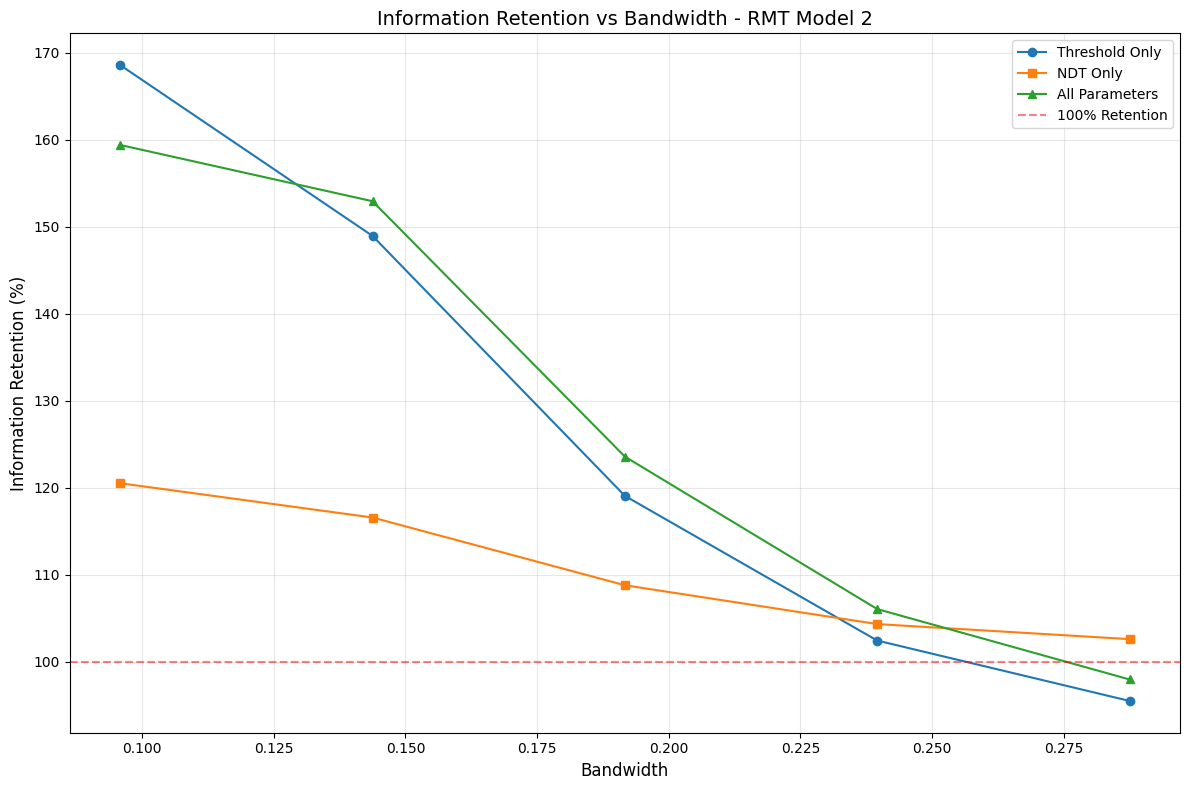

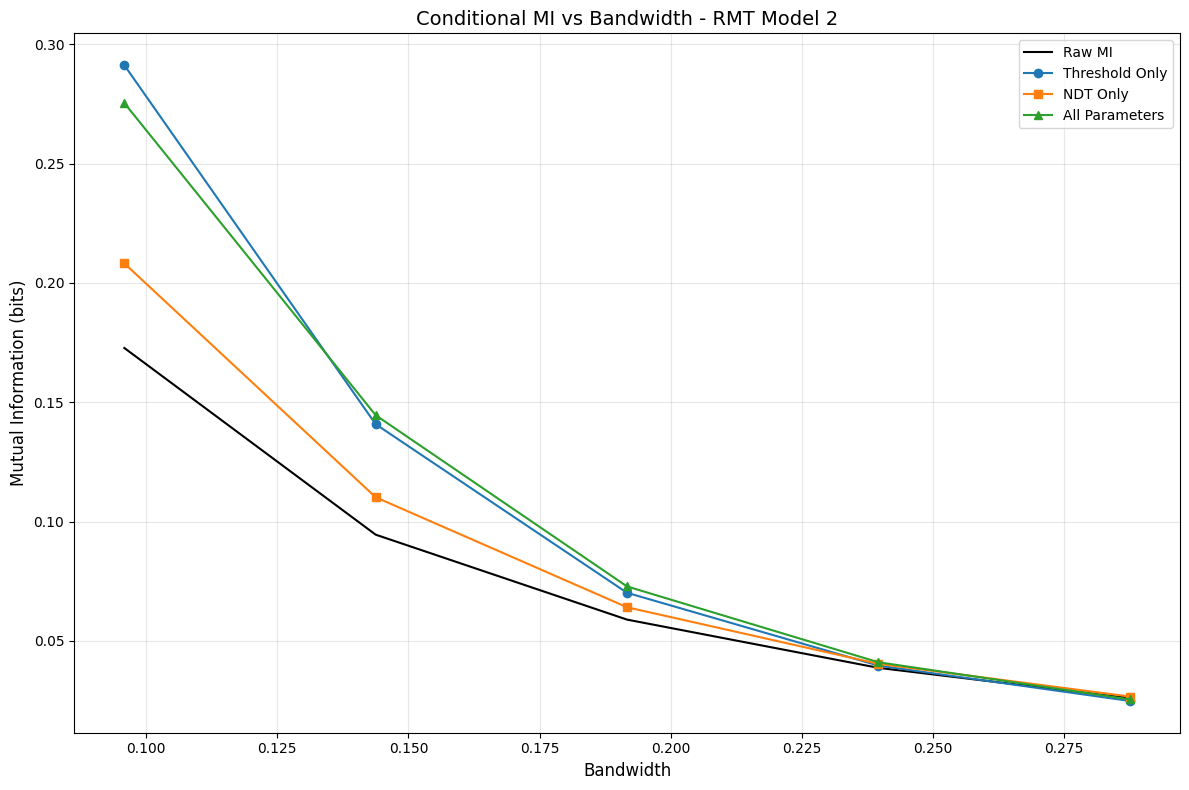

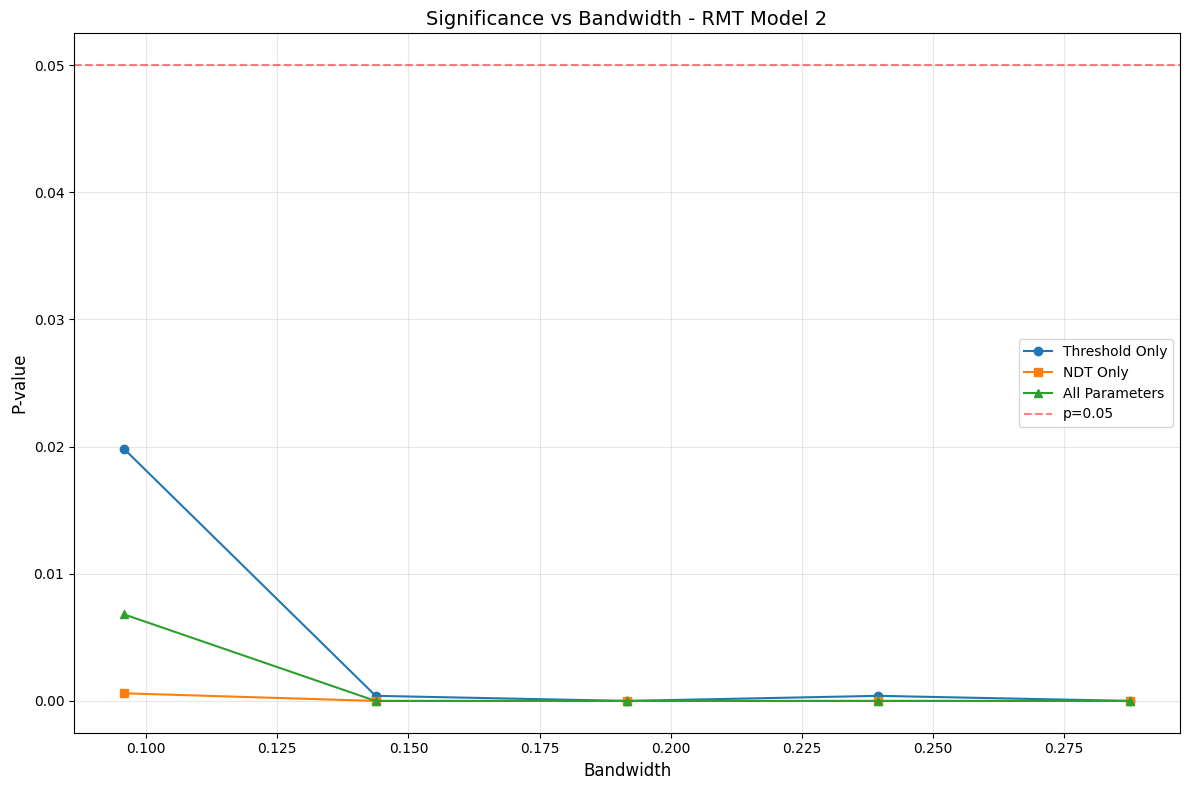


Summary of Results:

Bandwidth: 0.0958
Raw MI: 0.1727 bits
Threshold-only retention: 168.6% (p=0.0198)
NDT-only retention: 120.5% (p=0.0006)
All parameters retention: 159.4% (p=0.0068)

Bandwidth: 0.1438
Raw MI: 0.0945 bits
Threshold-only retention: 149.0% (p=0.0004)
NDT-only retention: 116.6% (p=0.0000)
All parameters retention: 152.9% (p=0.0000)

Bandwidth: 0.1917
Raw MI: 0.0589 bits
Threshold-only retention: 119.1% (p=0.0000)
NDT-only retention: 108.8% (p=0.0000)
All parameters retention: 123.6% (p=0.0000)

Bandwidth: 0.2396
Raw MI: 0.0387 bits
Threshold-only retention: 102.4% (p=0.0004)
NDT-only retention: 104.3% (p=0.0000)
All parameters retention: 106.0% (p=0.0000)

Bandwidth: 0.2875
Raw MI: 0.0260 bits
Threshold-only retention: 95.5% (p=0.0000)
NDT-only retention: 102.6% (p=0.0000)
All parameters retention: 98.0% (p=0.0000)

Analyzing bandwidth: 0.0958
Calculating conditional MI for a_mean_s1...
Calculating conditional MI for a_mean_s2...
Calculating conditional MI for ndt_mean

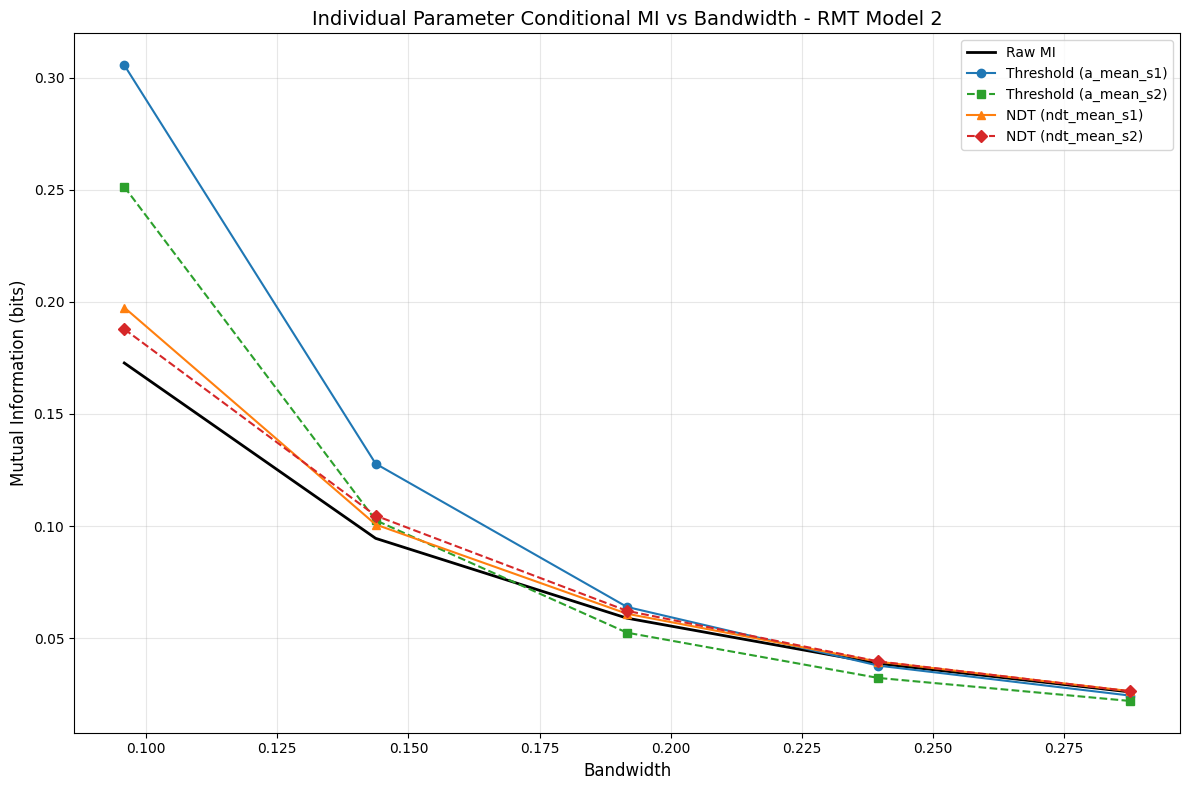

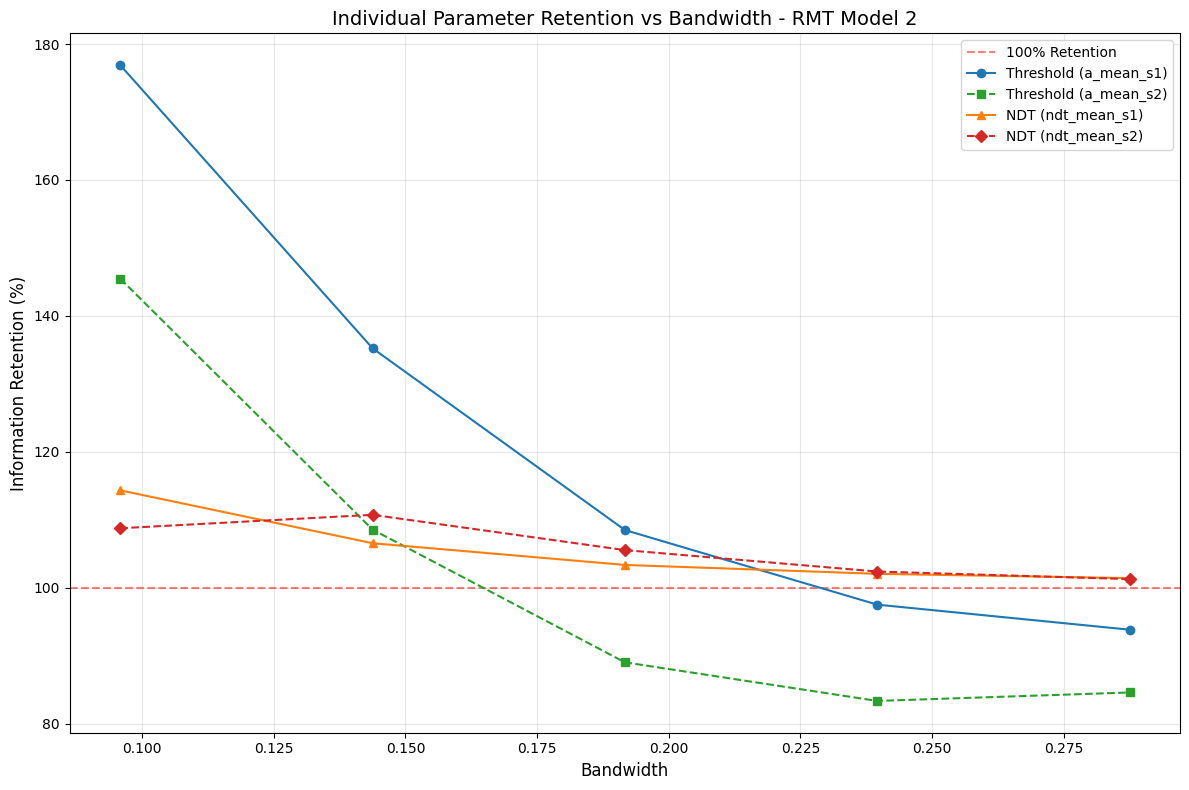

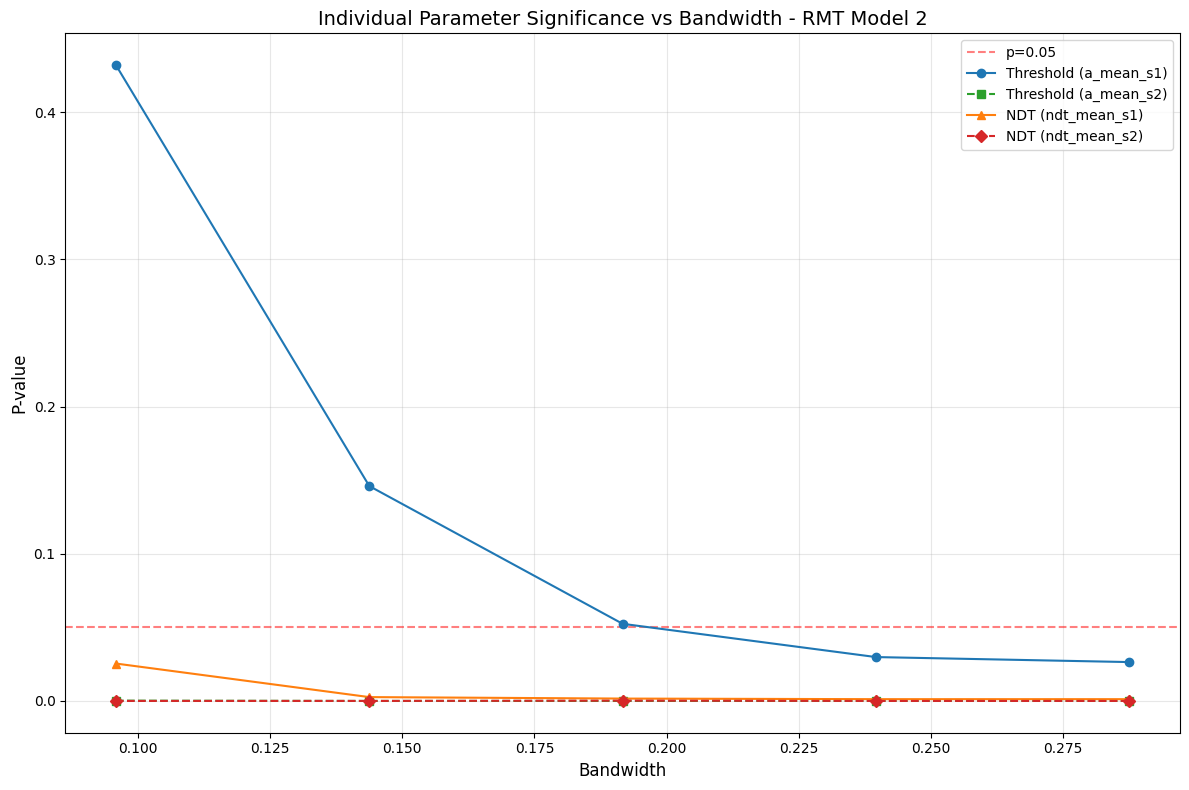

In [1]:
import NewMI_First
import numpy as np
import matplotlib.pyplot as plt

# Load your data
session1_path = 'Model2 LDT RMT/EZ_recognition_memory_part1_transformed.csv'
session2_path = 'Model2 LDT RMT/EZ_recognition_memory_part2_transformed.csv'
df_merged = NewMI_First.load_and_merge(session1_path, session2_path)

# Initialize analyzer
analyzer = NewMI_First.MutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Define a range of bandwidths to test
# Using a logarithmic scale to better explore the parameter space
base_bandwidth = np.std(analyzer.data['alpha_s1'].values) * (4/(3*len(analyzer.data)))**(1/5)
bandwidths = [
    base_bandwidth * 1.0,  # Original Silverman's rule
    base_bandwidth * 1.5,  # 1.5x Silverman
    base_bandwidth * 2.0,  # 2x Silverman
    base_bandwidth * 2.5,  # 2.5x Silverman
    base_bandwidth * 3.0   # 3x Silverman
]

print(f"Base bandwidth (Silverman's rule): {base_bandwidth:.4f}")
print(f"Testing bandwidths: {[f'{bw:.4f}' for bw in bandwidths]}")

# Set verbose output to False to reduce output clutter
import warnings
warnings.filterwarnings('ignore')

# Run the bandwidth sensitivity analysis for conditional MI
bandwidth_results = analyzer.conditional_mi_bandwidth_sensitivity(
    feature='alpha_s1',
    target='alpha_s2',
    control_vars=control_vars,
    bandwidths=bandwidths,
    alpha=1,  # Shrinkage parameter
    dataset_name="RMT Model 2"
)

# The method automatically produces plots, but we can also print some key results
print("\nSummary of Results:")
for i, bw in enumerate(bandwidth_results['bandwidths']):
    print(f"\nBandwidth: {bw:.4f}")
    print(f"Raw MI: {bandwidth_results['raw_mi'][i]:.4f} bits")
    
    if 'retention_threshold' in bandwidth_results:
        print(f"Threshold-only retention: {bandwidth_results['retention_threshold'][i]:.1f}% (p={bandwidth_results['p_values_threshold'][i]:.4f})")
    
    if 'retention_ndt' in bandwidth_results:
        print(f"NDT-only retention: {bandwidth_results['retention_ndt'][i]:.1f}% (p={bandwidth_results['p_values_ndt'][i]:.4f})")
    
    if 'retention_all' in bandwidth_results:
        print(f"All parameters retention: {bandwidth_results['retention_all'][i]:.1f}% (p={bandwidth_results['p_values_all'][i]:.4f})")
        

# Run the individual parameter analysis
individual_results = analyzer.individual_parameter_sensitivity(
    feature='alpha_s1',
    target='alpha_s2',
    control_vars=control_vars,
    bandwidths=bandwidths,
    alpha=1,
    dataset_name="RMT Model 2"
)

Available columns in session 1: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s1', 'ndt_mean_s1', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s2', 'ndt_mean_s2', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: ID
Base bandwidth (Silverman's rule): 0.0888
Testing bandwidths: ['0.0888', '0.1332', '0.1776',

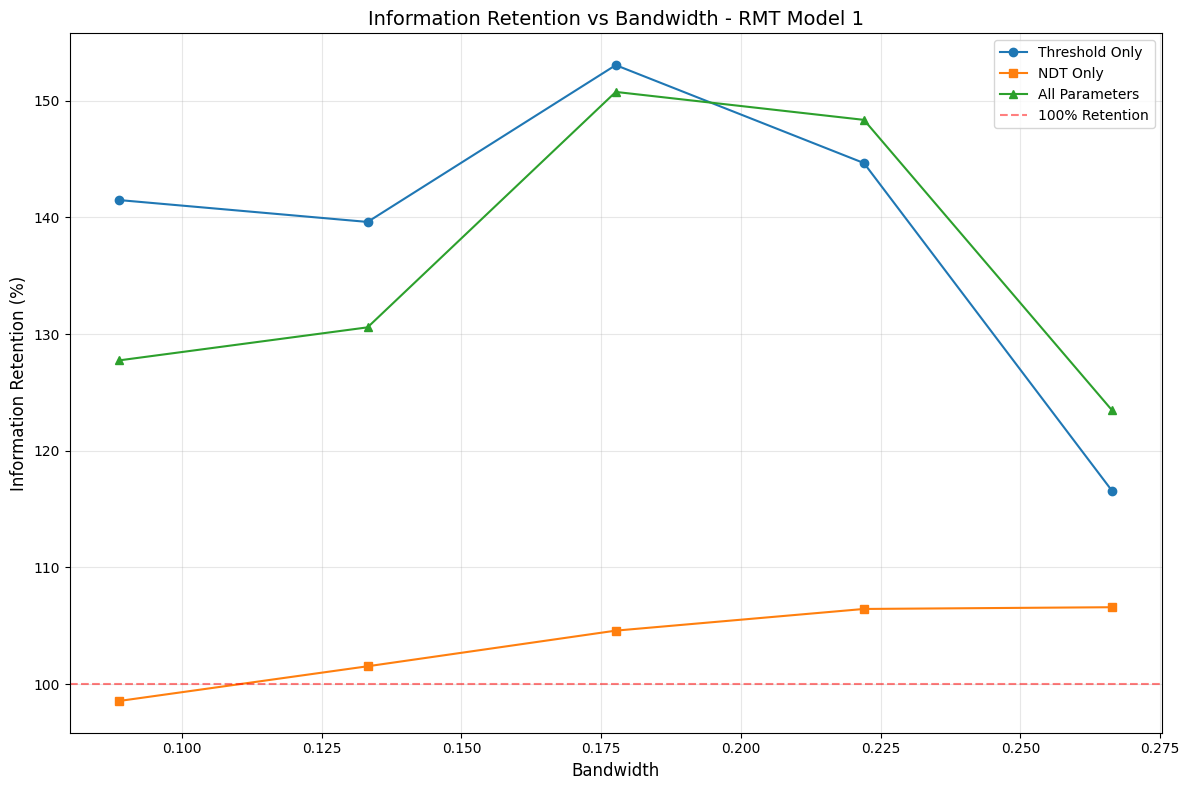

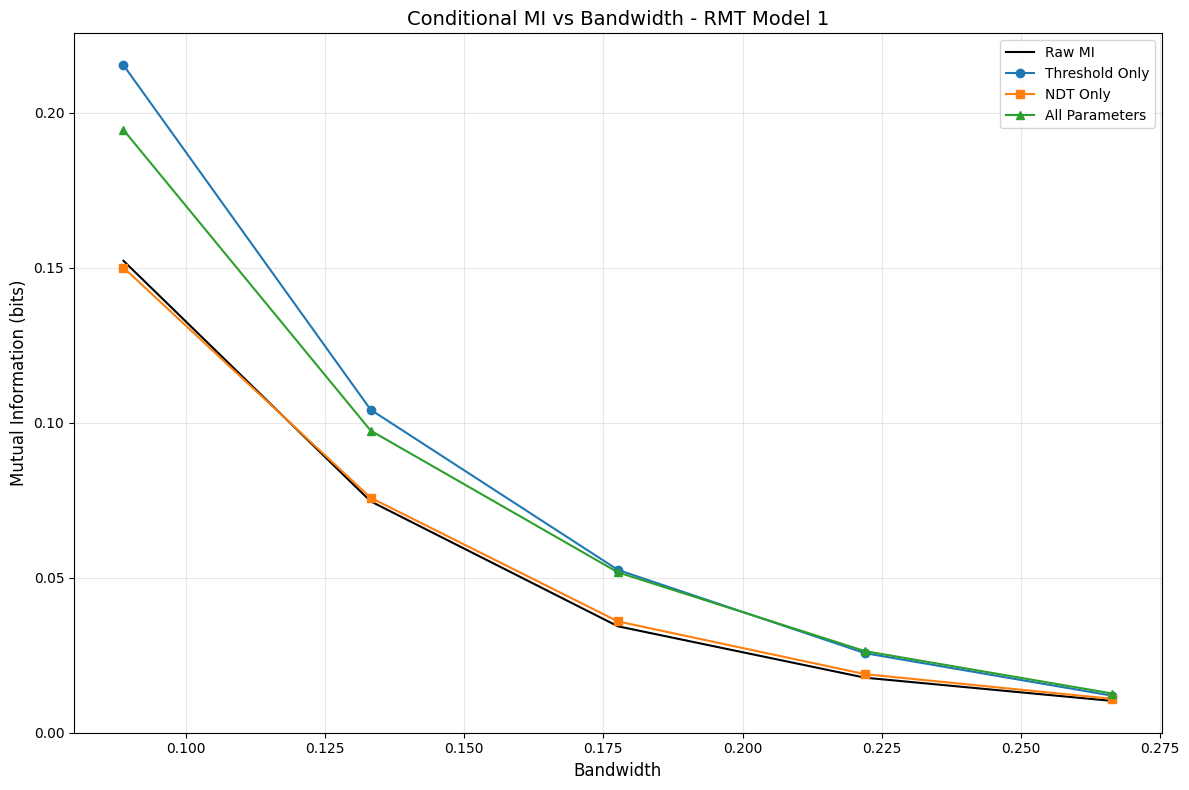

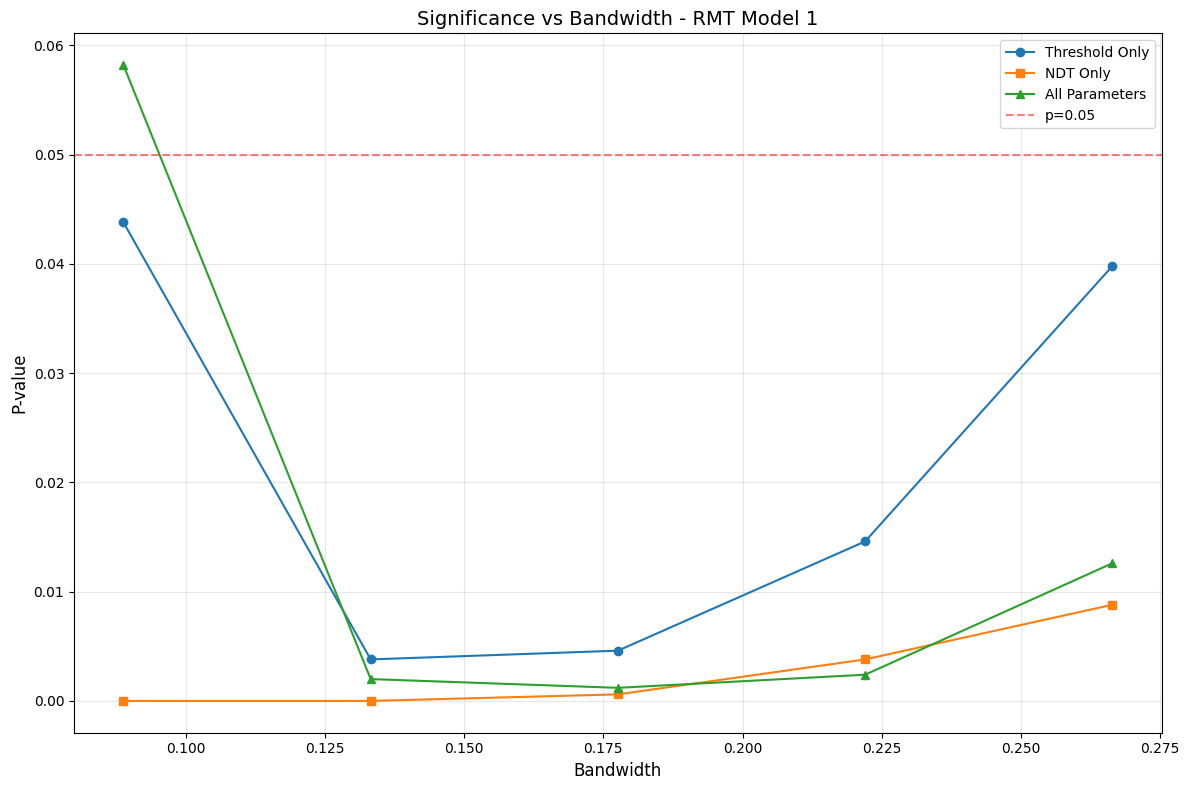


Summary of Results:

Bandwidth: 0.0888
Raw MI: 0.1523 bits
Threshold-only retention: 141.5% (p=0.0438)
NDT-only retention: 98.6% (p=0.0000)
All parameters retention: 127.7% (p=0.0582)

Bandwidth: 0.1332
Raw MI: 0.0746 bits
Threshold-only retention: 139.6% (p=0.0038)
NDT-only retention: 101.5% (p=0.0000)
All parameters retention: 130.6% (p=0.0020)

Bandwidth: 0.1776
Raw MI: 0.0343 bits
Threshold-only retention: 153.0% (p=0.0046)
NDT-only retention: 104.6% (p=0.0006)
All parameters retention: 150.7% (p=0.0012)

Bandwidth: 0.2220
Raw MI: 0.0177 bits
Threshold-only retention: 144.6% (p=0.0146)
NDT-only retention: 106.4% (p=0.0038)
All parameters retention: 148.3% (p=0.0024)

Bandwidth: 0.2664
Raw MI: 0.0102 bits
Threshold-only retention: 116.6% (p=0.0398)
NDT-only retention: 106.6% (p=0.0088)
All parameters retention: 123.5% (p=0.0126)

Analyzing bandwidth: 0.0888
Calculating conditional MI for a_mean_s1...
Calculating conditional MI for a_mean_s2...
Calculating conditional MI for ndt_mea

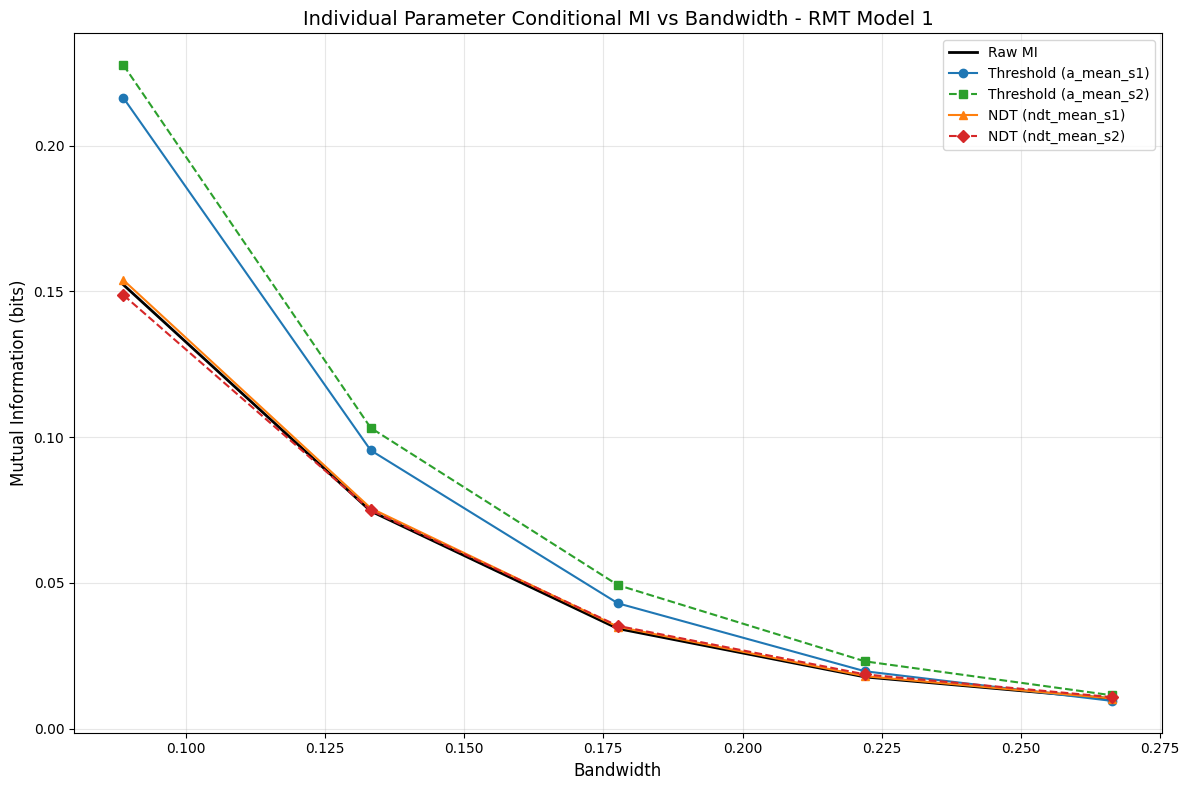

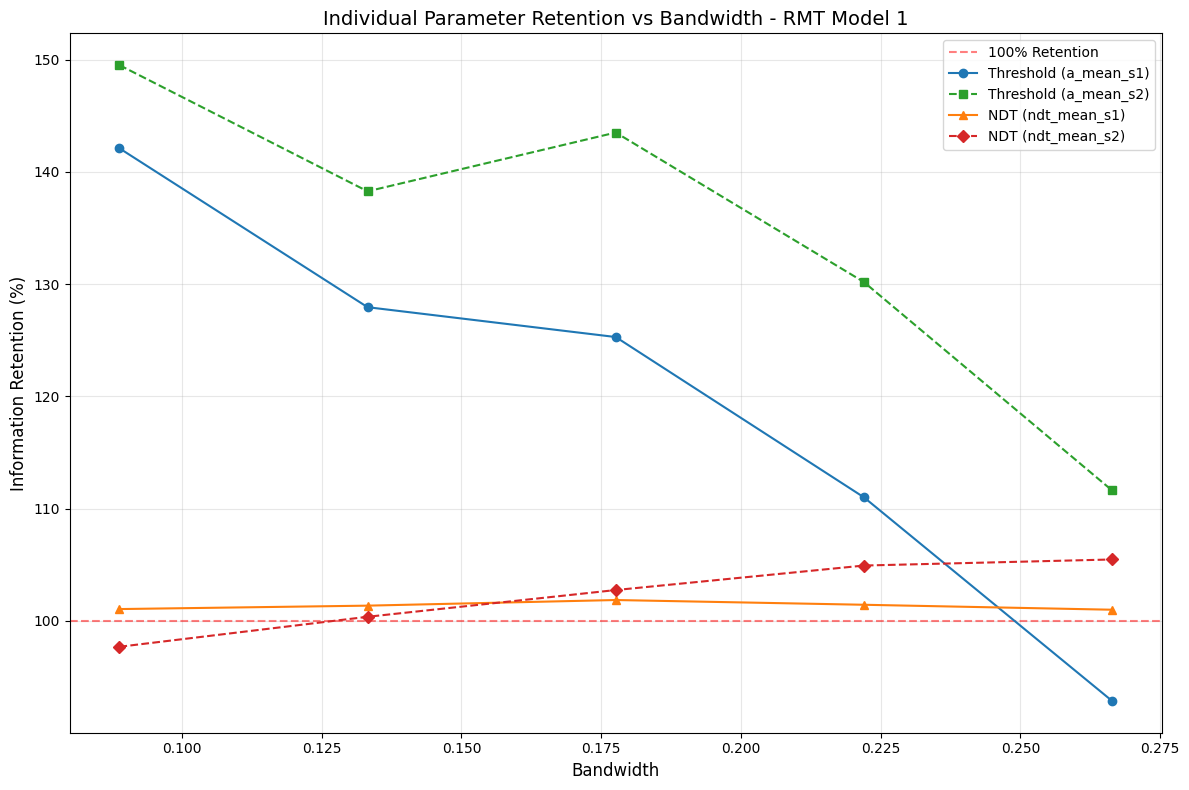

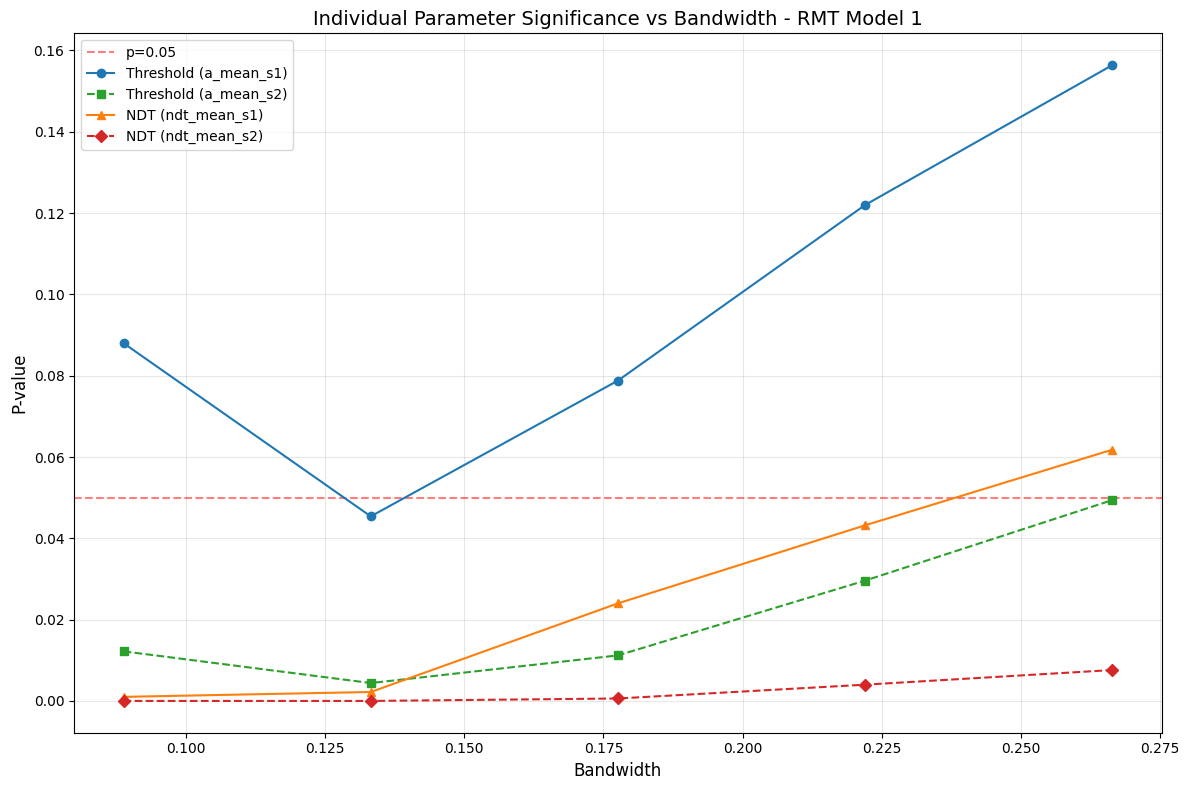

In [2]:

import NewMI_First

# Load your data
session1_path = 'Model1 LDT RMT/rmt_session_1_data_transformed.csv'  # replace with your actual path
session2_path = 'Model1 LDT RMT/rmt_session_2_data_transformed.csv'
df_merged = NewMI_First.load_and_merge(session1_path, session2_path)

analyzer = NewMI_First.MutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Define a range of bandwidths to test
# Using a logarithmic scale to better explore the parameter space
base_bandwidth = np.std(analyzer.data['alpha_s1'].values) * (4/(3*len(analyzer.data)))**(1/5)
bandwidths = [
    base_bandwidth * 1.0,  # Original Silverman's rule
    base_bandwidth * 1.5,  # 1.5x Silverman
    base_bandwidth * 2.0,  # 2x Silverman
    base_bandwidth * 2.5,  # 2.5x Silverman
    base_bandwidth * 3.0   # 3x Silverman
]

print(f"Base bandwidth (Silverman's rule): {base_bandwidth:.4f}")
print(f"Testing bandwidths: {[f'{bw:.4f}' for bw in bandwidths]}")

# Set verbose output to False to reduce output clutter
import warnings
warnings.filterwarnings('ignore')

# Run the bandwidth sensitivity analysis for conditional MI
bandwidth_results = analyzer.conditional_mi_bandwidth_sensitivity(
    feature='alpha_s1',
    target='alpha_s2',
    control_vars=control_vars,
    bandwidths=bandwidths,
    alpha=1,  # Shrinkage parameter
    dataset_name="RMT Model 1"
)

# The method automatically produces plots, but we can also print some key results
print("\nSummary of Results:")
for i, bw in enumerate(bandwidth_results['bandwidths']):
    print(f"\nBandwidth: {bw:.4f}")
    print(f"Raw MI: {bandwidth_results['raw_mi'][i]:.4f} bits")
    
    if 'retention_threshold' in bandwidth_results:
        print(f"Threshold-only retention: {bandwidth_results['retention_threshold'][i]:.1f}% (p={bandwidth_results['p_values_threshold'][i]:.4f})")
    
    if 'retention_ndt' in bandwidth_results:
        print(f"NDT-only retention: {bandwidth_results['retention_ndt'][i]:.1f}% (p={bandwidth_results['p_values_ndt'][i]:.4f})")
    
    if 'retention_all' in bandwidth_results:
        print(f"All parameters retention: {bandwidth_results['retention_all'][i]:.1f}% (p={bandwidth_results['p_values_all'][i]:.4f})")
# Run the individual parameter analysis
individual_results = analyzer.individual_parameter_sensitivity(
    feature='alpha_s1',
    target='alpha_s2',
    control_vars=control_vars,
    bandwidths=bandwidths,
    alpha=1,
    dataset_name="RMT Model 1"
)

Available columns in session 1: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s1', 'ndt_mean_s1', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s2', 'ndt_mean_s2', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: ID
Base bandwidth (Silverman's rule): 0.0895
Testing bandwidths: ['0.0895', '0.1343', '0.1791',

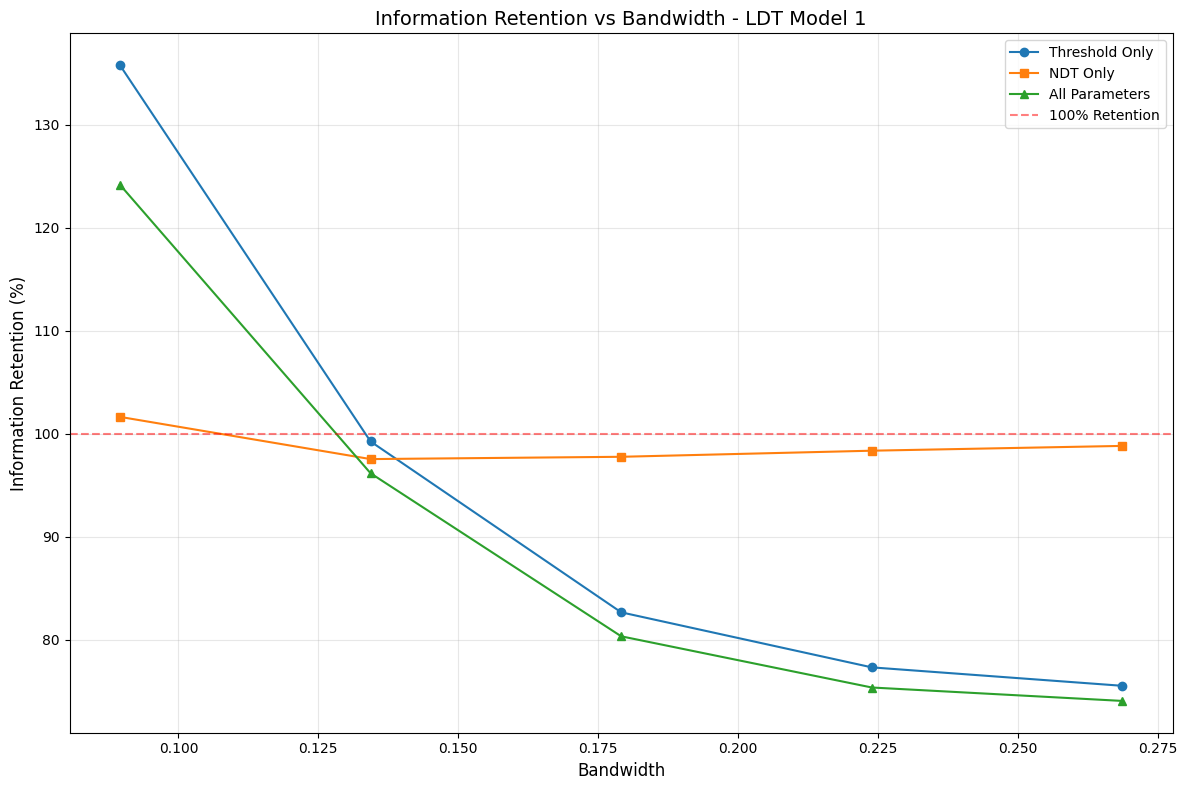

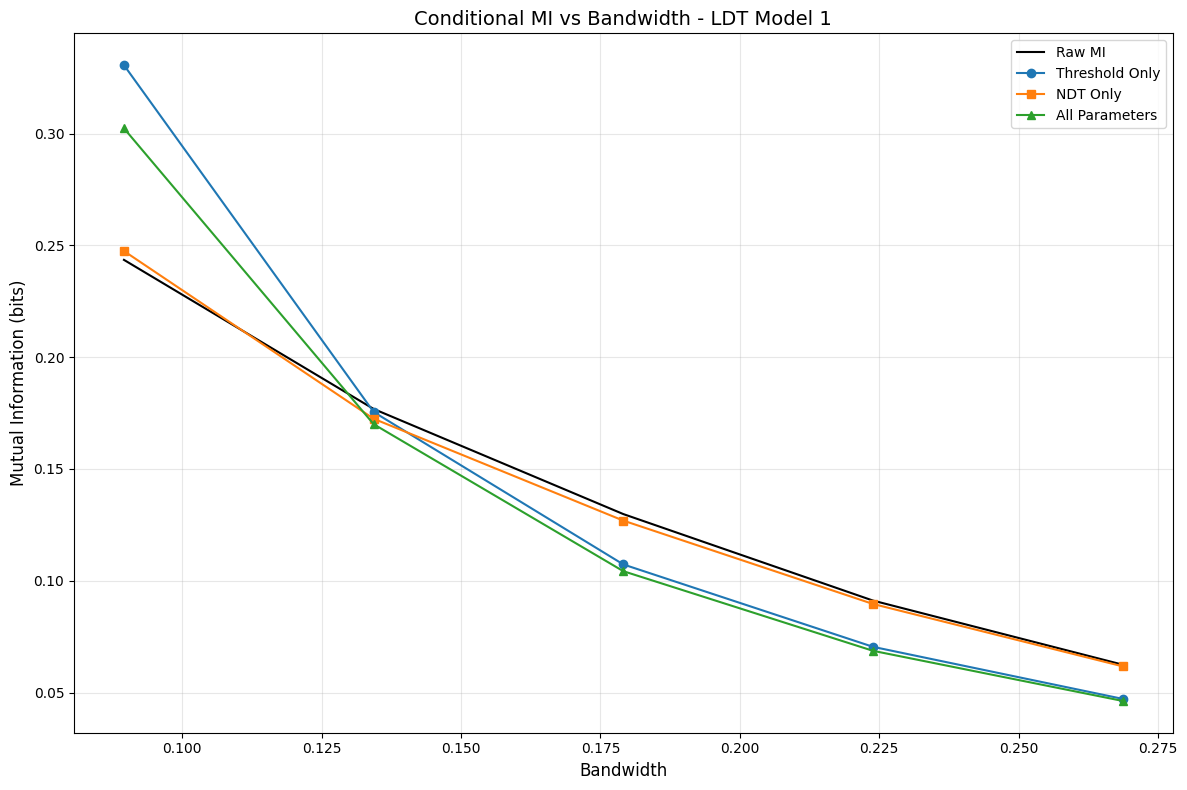

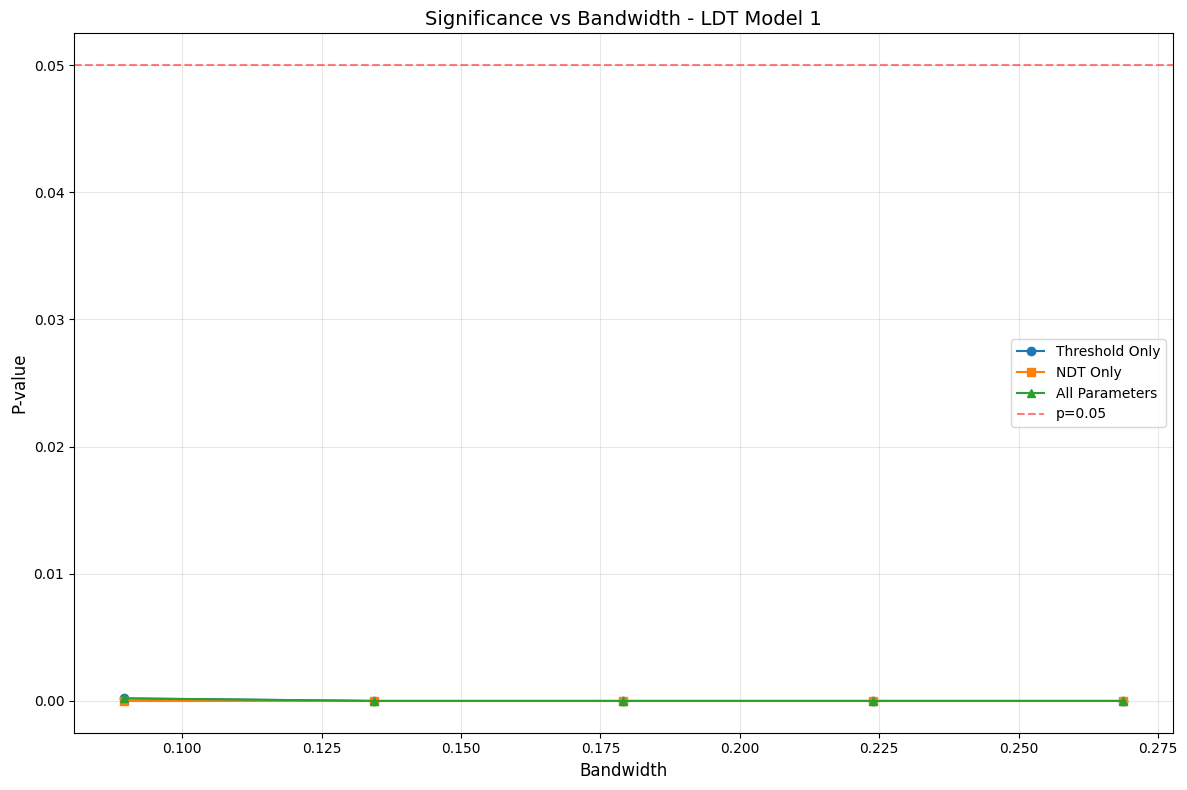


Summary of Results:

Bandwidth: 0.0895
Raw MI: 0.2435 bits
Threshold-only retention: 135.8% (p=0.0002)
NDT-only retention: 101.6% (p=0.0000)
All parameters retention: 124.2% (p=0.0002)

Bandwidth: 0.1343
Raw MI: 0.1768 bits
Threshold-only retention: 99.2% (p=0.0000)
NDT-only retention: 97.5% (p=0.0000)
All parameters retention: 96.2% (p=0.0000)

Bandwidth: 0.1791
Raw MI: 0.1298 bits
Threshold-only retention: 82.7% (p=0.0000)
NDT-only retention: 97.8% (p=0.0000)
All parameters retention: 80.3% (p=0.0000)

Bandwidth: 0.2239
Raw MI: 0.0912 bits
Threshold-only retention: 77.3% (p=0.0000)
NDT-only retention: 98.3% (p=0.0000)
All parameters retention: 75.4% (p=0.0000)

Bandwidth: 0.2686
Raw MI: 0.0625 bits
Threshold-only retention: 75.5% (p=0.0000)
NDT-only retention: 98.8% (p=0.0000)
All parameters retention: 74.1% (p=0.0000)

Analyzing bandwidth: 0.0895
Calculating conditional MI for a_mean_s1...
Calculating conditional MI for a_mean_s2...
Calculating conditional MI for ndt_mean_s1...
Cal

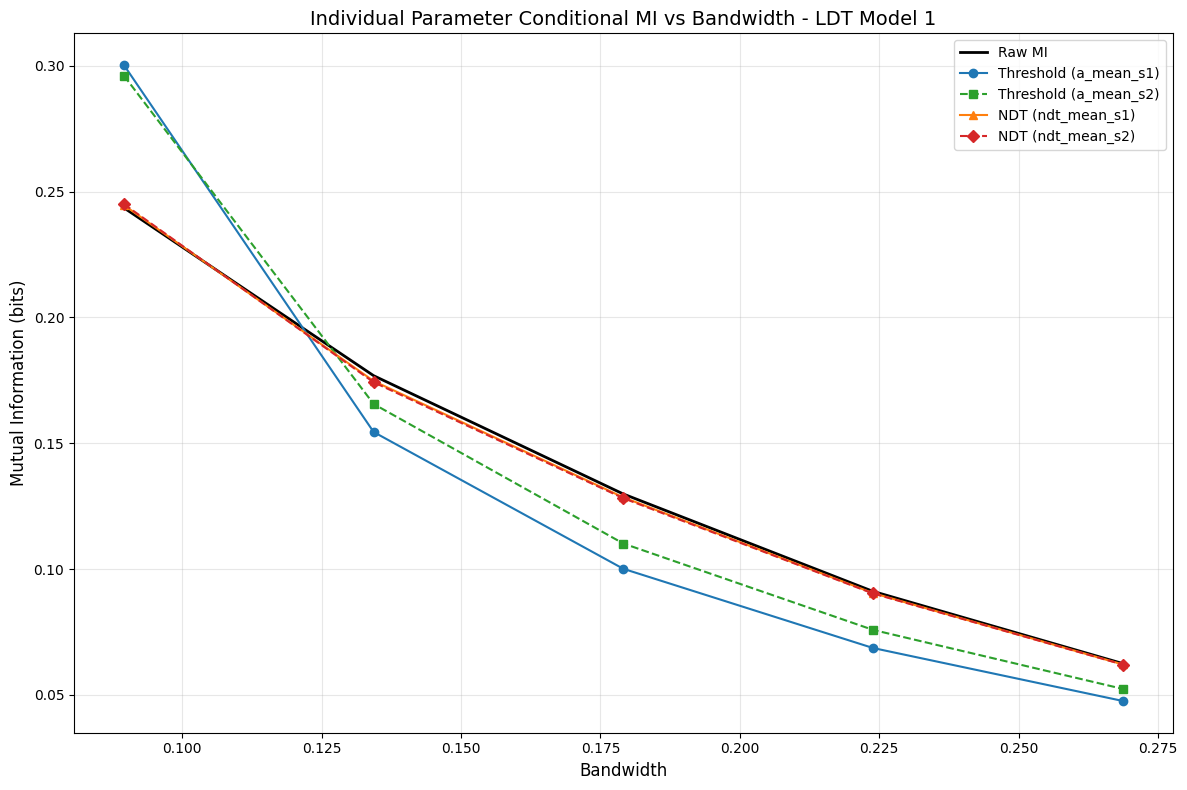

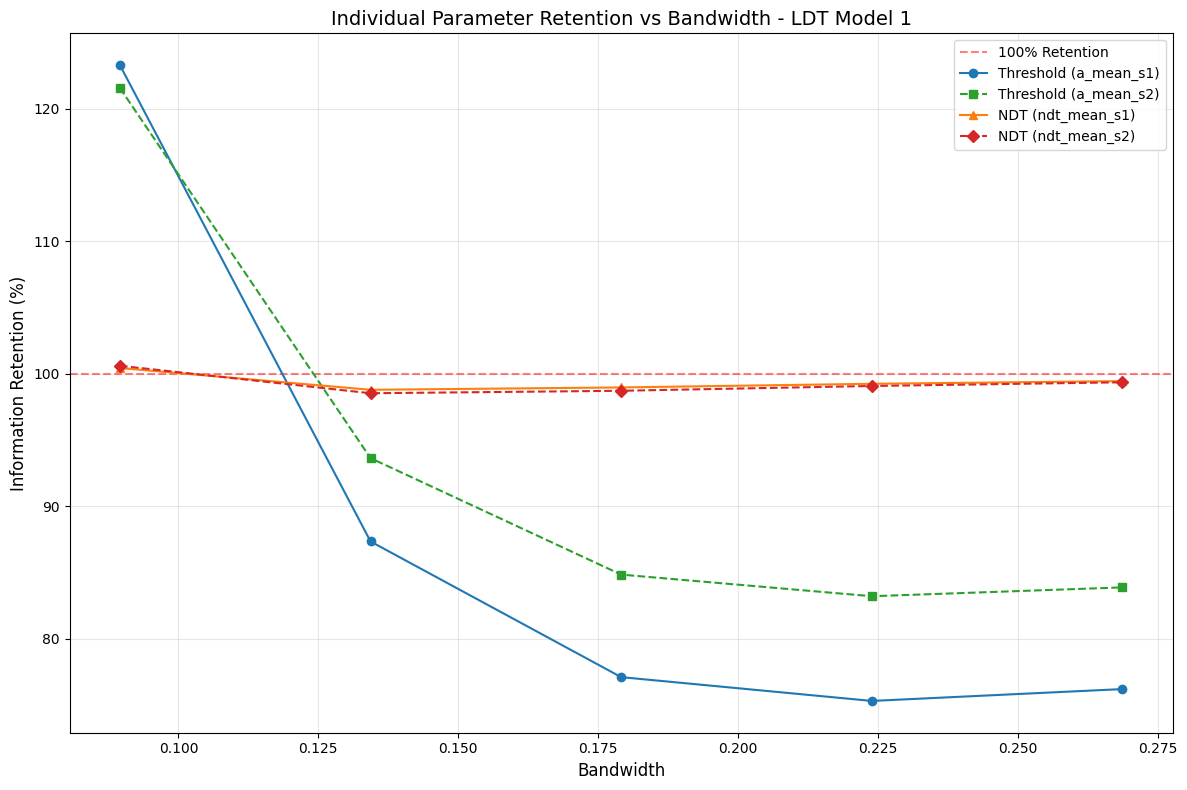

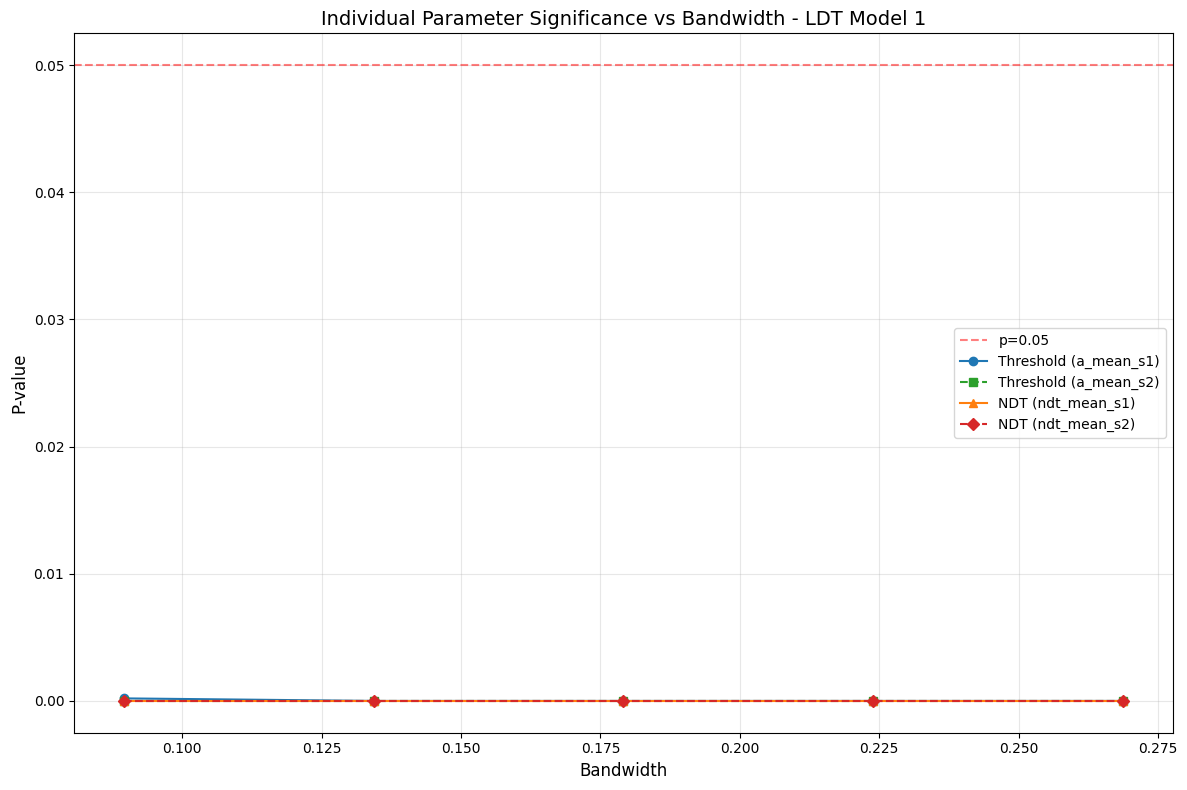

In [3]:
import NewMI_First

# Load your data
session1_path = 'Model1 LDT RMT/ldt_session_1_data_transformed.csv'  # replace with your actual path
session2_path = 'Model1 LDT RMT/ldt_session_2_data_transformed.csv'
df_merged = NewMI_First.load_and_merge(session1_path, session2_path)

analyzer = NewMI_First.MutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Define a range of bandwidths to test
# Using a logarithmic scale to better explore the parameter space
base_bandwidth = np.std(analyzer.data['alpha_s1'].values) * (4/(3*len(analyzer.data)))**(1/5)
bandwidths = [
    base_bandwidth * 1.0,  # Original Silverman's rule
    base_bandwidth * 1.5,  # 1.5x Silverman
    base_bandwidth * 2.0,  # 2x Silverman
    base_bandwidth * 2.5,  # 2.5x Silverman
    base_bandwidth * 3.0   # 3x Silverman
]

print(f"Base bandwidth (Silverman's rule): {base_bandwidth:.4f}")
print(f"Testing bandwidths: {[f'{bw:.4f}' for bw in bandwidths]}")

# Set verbose output to False to reduce output clutter
import warnings
warnings.filterwarnings('ignore')

# Run the bandwidth sensitivity analysis for conditional MI
bandwidth_results = analyzer.conditional_mi_bandwidth_sensitivity(
    feature='alpha_s1',
    target='alpha_s2',
    control_vars=control_vars,
    bandwidths=bandwidths,
    alpha=1,  # Shrinkage parameter
    dataset_name="LDT Model 1"
)

# The method automatically produces plots, but we can also print some key results
print("\nSummary of Results:")
for i, bw in enumerate(bandwidth_results['bandwidths']):
    print(f"\nBandwidth: {bw:.4f}")
    print(f"Raw MI: {bandwidth_results['raw_mi'][i]:.4f} bits")
    
    if 'retention_threshold' in bandwidth_results:
        print(f"Threshold-only retention: {bandwidth_results['retention_threshold'][i]:.1f}% (p={bandwidth_results['p_values_threshold'][i]:.4f})")
    
    if 'retention_ndt' in bandwidth_results:
        print(f"NDT-only retention: {bandwidth_results['retention_ndt'][i]:.1f}% (p={bandwidth_results['p_values_ndt'][i]:.4f})")
    
    if 'retention_all' in bandwidth_results:
        print(f"All parameters retention: {bandwidth_results['retention_all'][i]:.1f}% (p={bandwidth_results['p_values_all'][i]:.4f})")

# Run the individual parameter analysis
individual_results = analyzer.individual_parameter_sensitivity(
    feature='alpha_s1',
    target='alpha_s2',
    control_vars=control_vars,
    bandwidths=bandwidths,
    alpha=1,
    dataset_name="LDT Model 1"
)

Available columns in session 1: ['Experiment', 'v1_mean', 'v2_mean', 'a_mean_s1', 'ndt_mean_s1', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'error_array', 'RT_Cor_arr', 'q1_C', 'q2_C', 'q3_C', 'q4_C', 'q1_E', 'q2_E', 'q3_E', 'q4_E', 'participant_ID', 'alpha_mean_shifted', 'alpha_mean_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_percentage_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Experiment', 'v1_mean', 'v2_mean', 'a_mean_s2', 'ndt_mean_s2', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'error_array', 'RT_Cor_arr', 'q1_C', 'q2_C', 'q3_C', 'q4_C', 'q1_E', 'q2_E', 'q3_E', 'q4_E', 'participant_ID', 'alpha_mean_shifted', 'alpha_mean_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_percentage_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: participant_ID
Base bandwidth (Silverman's rule):

Permutation test p-value: 0.0000
Calculating conditional MI for threshold parameters...

Diagnostic Information for Conditional MI (Threshold Parameters):
Number of threshold variables: 2
Threshold variables: ['a_mean_s1', 'a_mean_s2']
Sample size: 101
Dimensionality of threshold matrix: (101, 2)

Correlations between threshold variables:
a_mean_s1 - a_mean_s2: r = 0.5233
Using bandwidth: 0.0930

Intermediate calculation steps:
Mean(log_pxyz + log_pz): 1.8588
Mean(log_pxz + log_pyz): 1.4942
Final Threshold CMI: 0.3646
Permutation test p-value: 0.0000
Calculating conditional MI for NDT parameters...

Diagnostic Information for Conditional MI (NDT Parameters):
Number of NDT variables: 2
NDT variables: ['ndt_mean_s1', 'ndt_mean_s2']
Sample size: 101
Dimensionality of NDT matrix: (101, 2)

Correlations between NDT variables:
ndt_mean_s1 - ndt_mean_s2: r = 0.4316
Using bandwidth: 0.0930

Intermediate calculation steps:
Mean(log_pxyz + log_pz): 5.5998
Mean(log_pxz + log_pyz): 5.2986
Final ND

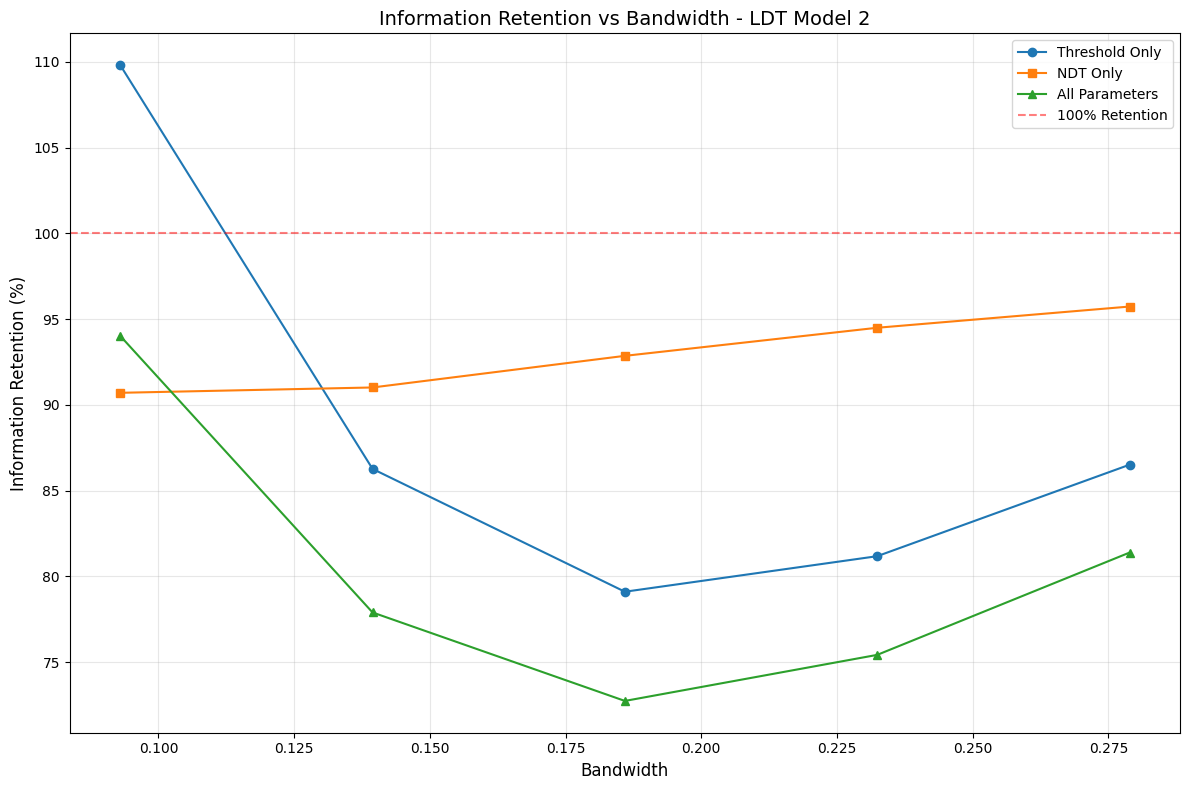

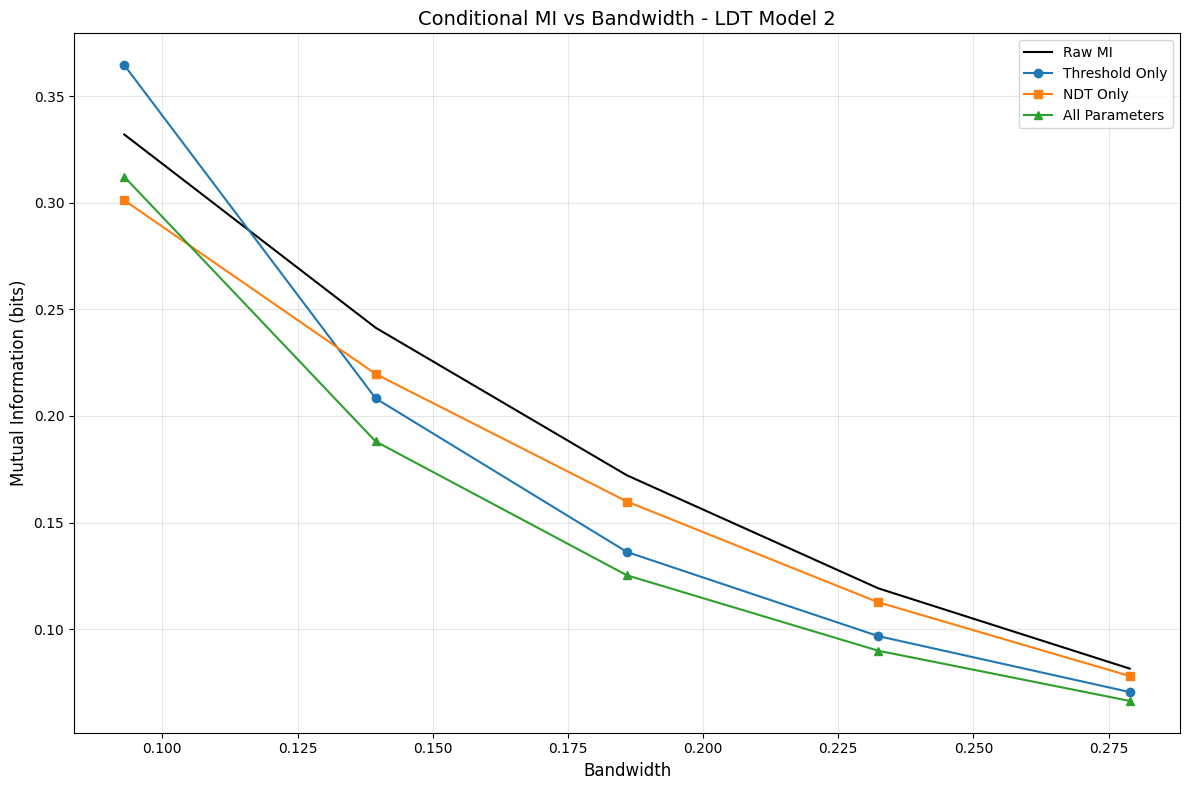

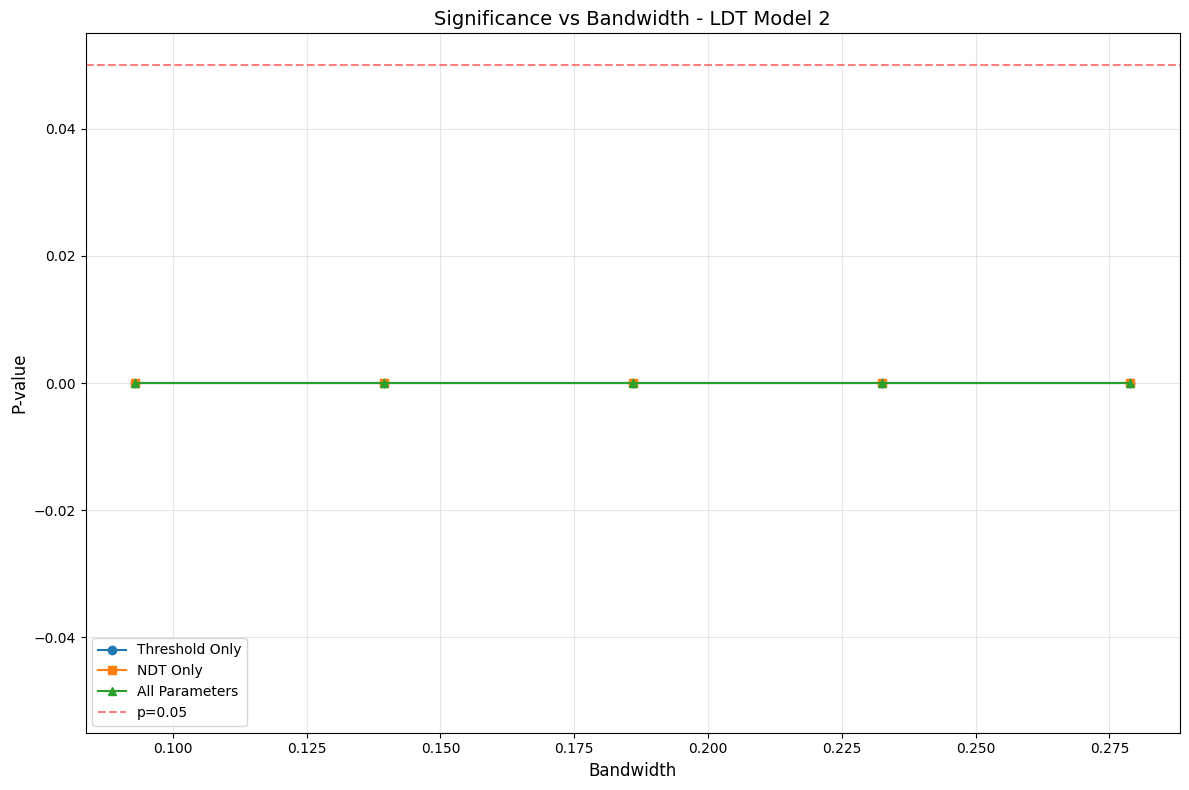


Summary of Results:

Bandwidth: 0.0930
Raw MI: 0.3320 bits
Threshold-only retention: 109.8% (p=0.0000)
NDT-only retention: 90.7% (p=0.0000)
All parameters retention: 94.0% (p=0.0000)

Bandwidth: 0.1394
Raw MI: 0.2414 bits
Threshold-only retention: 86.3% (p=0.0000)
NDT-only retention: 91.0% (p=0.0000)
All parameters retention: 77.9% (p=0.0000)

Bandwidth: 0.1859
Raw MI: 0.1721 bits
Threshold-only retention: 79.1% (p=0.0000)
NDT-only retention: 92.9% (p=0.0000)
All parameters retention: 72.7% (p=0.0000)

Bandwidth: 0.2324
Raw MI: 0.1191 bits
Threshold-only retention: 81.2% (p=0.0000)
NDT-only retention: 94.5% (p=0.0000)
All parameters retention: 75.4% (p=0.0000)

Bandwidth: 0.2789
Raw MI: 0.0815 bits
Threshold-only retention: 86.5% (p=0.0000)
NDT-only retention: 95.7% (p=0.0000)
All parameters retention: 81.4% (p=0.0000)

Analyzing bandwidth: 0.0930
Calculating conditional MI for a_mean_s1...
Calculating conditional MI for a_mean_s2...
Calculating conditional MI for ndt_mean_s1...
Calcu

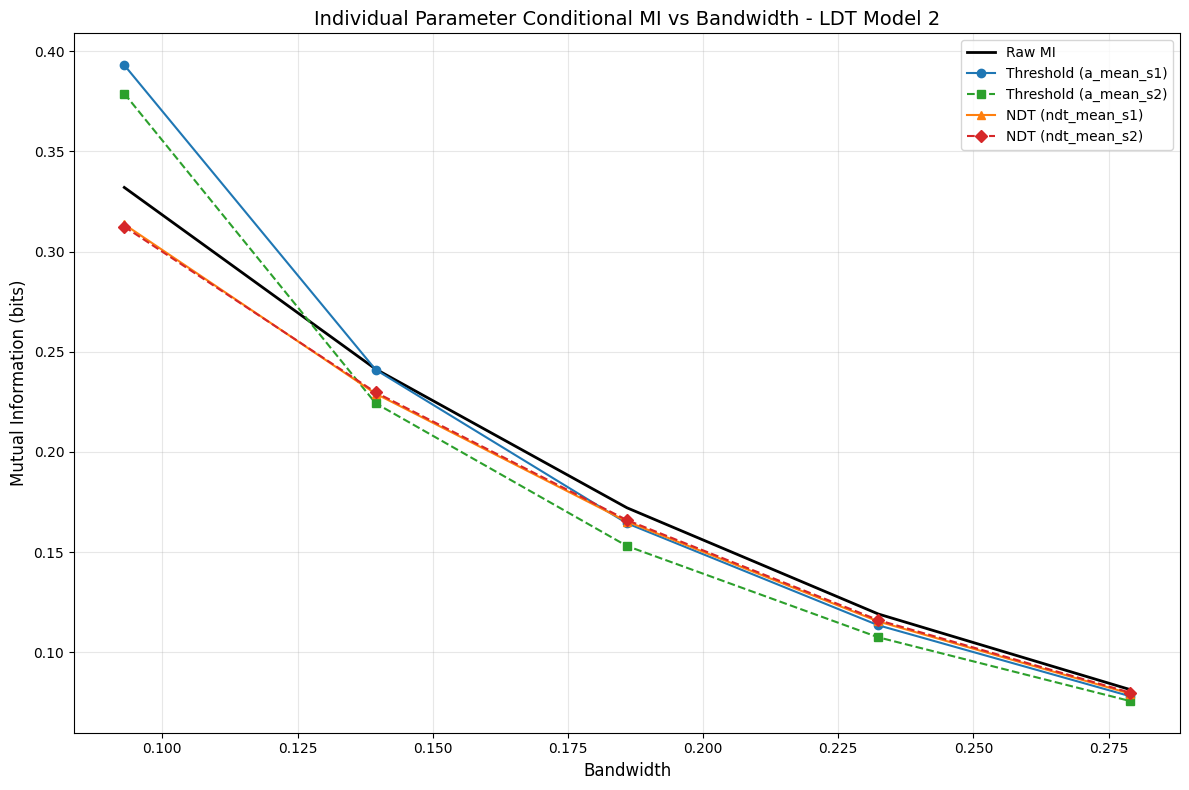

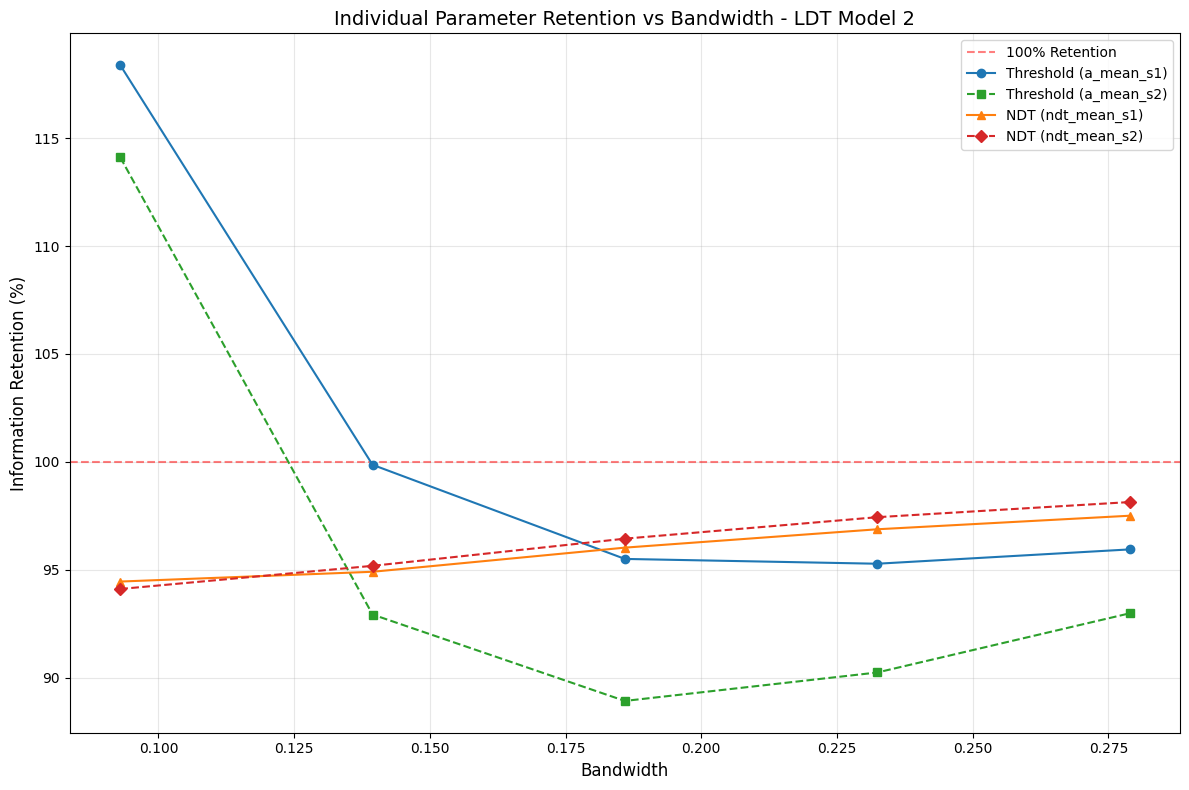

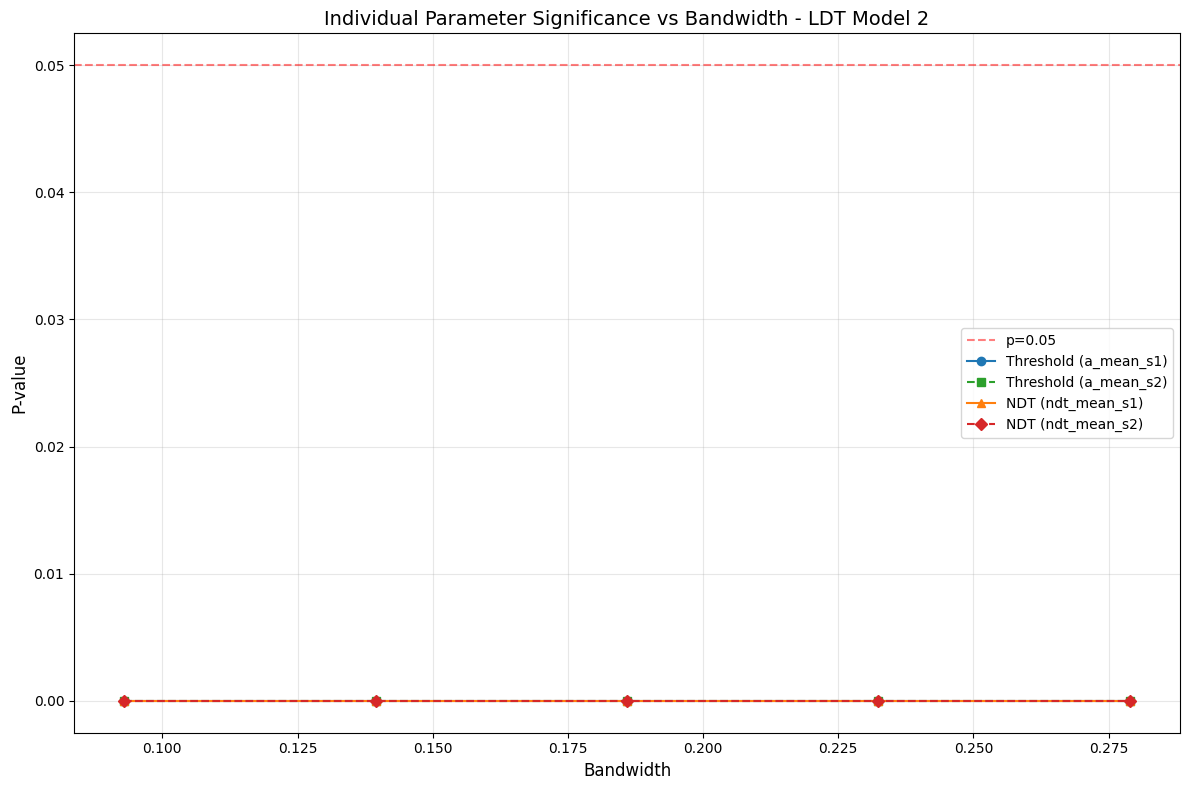

In [4]:
import NewMI_First

# Load your data
session1_path = 'Model2 LDT RMT/EZ_lexical_decision_part1_transformed.csv'  # replace with your actual path
session2_path = 'Model2 LDT RMT/EZ_lexical_decision_part2_transformed.csv'
df_merged = NewMI_First.load_and_merge(session1_path, session2_path)

analyzer = NewMI_First.MutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Define a range of bandwidths to test
# Using a logarithmic scale to better explore the parameter space
base_bandwidth = np.std(analyzer.data['alpha_s1'].values) * (4/(3*len(analyzer.data)))**(1/5)
bandwidths = [
    base_bandwidth * 1.0,  # Original Silverman's rule
    base_bandwidth * 1.5,  # 1.5x Silverman
    base_bandwidth * 2.0,  # 2x Silverman
    base_bandwidth * 2.5,  # 2.5x Silverman
    base_bandwidth * 3.0   # 3x Silverman
]

print(f"Base bandwidth (Silverman's rule): {base_bandwidth:.4f}")
print(f"Testing bandwidths: {[f'{bw:.4f}' for bw in bandwidths]}")

# Set verbose output to False to reduce output clutter
import warnings
warnings.filterwarnings('ignore')

# Run the bandwidth sensitivity analysis for conditional MI
bandwidth_results = analyzer.conditional_mi_bandwidth_sensitivity(
    feature='alpha_s1',
    target='alpha_s2',
    control_vars=control_vars,
    bandwidths=bandwidths,
    alpha=1,  # Shrinkage parameter
    dataset_name="LDT Model 2"
)

# The method automatically produces plots, but we can also print some key results
print("\nSummary of Results:")
for i, bw in enumerate(bandwidth_results['bandwidths']):
    print(f"\nBandwidth: {bw:.4f}")
    print(f"Raw MI: {bandwidth_results['raw_mi'][i]:.4f} bits")
    
    if 'retention_threshold' in bandwidth_results:
        print(f"Threshold-only retention: {bandwidth_results['retention_threshold'][i]:.1f}% (p={bandwidth_results['p_values_threshold'][i]:.4f})")
    
    if 'retention_ndt' in bandwidth_results:
        print(f"NDT-only retention: {bandwidth_results['retention_ndt'][i]:.1f}% (p={bandwidth_results['p_values_ndt'][i]:.4f})")
    
    if 'retention_all' in bandwidth_results:
        print(f"All parameters retention: {bandwidth_results['retention_all'][i]:.1f}% (p={bandwidth_results['p_values_all'][i]:.4f})")

# Run the individual parameter analysis
individual_results = analyzer.individual_parameter_sensitivity(
    feature='alpha_s1',
    target='alpha_s2',
    control_vars=control_vars,
    bandwidths=bandwidths,
    alpha=1,
    dataset_name="LDT Model 2"
)

In [ ]:
import NewMI_First

# Load your data
session1_path = 'Model1 ELP/Transformed_recoverd_param_ELP_S1_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'
session2_path = 'Model1 ELP/Transformed_recoverd_param_ELP_S2_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'

df_merged = NewMI_First.load_and_merge(session1_path, session2_path)

# Initialize analyzer
analyzer = NewMI_First.MutualInformationAnalyzer(df_merged)



# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Define a range of bandwidths to test
# Using a logarithmic scale to better explore the parameter space
base_bandwidth = np.std(analyzer.data['alpha_s1'].values) * (4/(3*len(analyzer.data)))**(1/5)
bandwidths = [
    base_bandwidth * 1.0,  # Original Silverman's rule
    base_bandwidth * 1.5,  # 1.5x Silverman
    base_bandwidth * 2.0,  # 2x Silverman
    base_bandwidth * 2.5,  # 2.5x Silverman
    base_bandwidth * 3.0   # 3x Silverman
]

print(f"Base bandwidth (Silverman's rule): {base_bandwidth:.4f}")
print(f"Testing bandwidths: {[f'{bw:.4f}' for bw in bandwidths]}")

# Set verbose output to False to reduce output clutter
import warnings
warnings.filterwarnings('ignore')

# Run the bandwidth sensitivity analysis for conditional MI
bandwidth_results = analyzer.conditional_mi_bandwidth_sensitivity(
    feature='alpha_s1',
    target='alpha_s2',
    control_vars=control_vars,
    bandwidths=bandwidths,
    alpha=1,  # Shrinkage parameter
    dataset_name="ELP Model 1"
)

# The method automatically produces plots, but we can also print some key results
print("\nSummary of Results:")
for i, bw in enumerate(bandwidth_results['bandwidths']):
    print(f"\nBandwidth: {bw:.4f}")
    print(f"Raw MI: {bandwidth_results['raw_mi'][i]:.4f} bits")
    
    if 'retention_threshold' in bandwidth_results:
        print(f"Threshold-only retention: {bandwidth_results['retention_threshold'][i]:.1f}% (p={bandwidth_results['p_values_threshold'][i]:.4f})")
    
    if 'retention_ndt' in bandwidth_results:
        print(f"NDT-only retention: {bandwidth_results['retention_ndt'][i]:.1f}% (p={bandwidth_results['p_values_ndt'][i]:.4f})")
    
    if 'retention_all' in bandwidth_results:
        print(f"All parameters retention: {bandwidth_results['retention_all'][i]:.1f}% (p={bandwidth_results['p_values_all'][i]:.4f})")

# Run the individual parameter analysis
individual_results = analyzer.individual_parameter_sensitivity(
    feature='alpha_s1',
    target='alpha_s2',
    control_vars=control_vars,
    bandwidths=bandwidths,
    alpha=1,
    dataset_name="ELP Model 1"
)

Available columns in session 1: ['Unnamed: 0', 'participant', 'v1', 'v2', 'zr', 'a_mean_s1', 'ndt_mean_s1', 'sndt', 'alpha', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'log_alpha_mean', 'alpha_capped', 'alpha_shifted', 'alpha_arcsin', 'alpha_arcsin_positive', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_arcsin_positive', 'accuracy_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'participant', 'v1', 'v2', 'zr', 'a_mean_s2', 'ndt_mean_s2', 'sndt', 'alpha', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'log_alpha_mean', 'alpha_capped', 'alpha_shifted', 'alpha_arcsin', 'alpha_arcsin_positive', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_arcsin_positive', 'accuracy_boxcox_after_arcsin']
Using identifier column: participant
Base bandwidth (Silverman's rule): 0.0782
Testing bandwidths: ['0.0782', '0.1173', '0.1563', '0.1954', '0.2345']

Analyzi

# ELP Model 2

Available columns in session 1: ['Unnamed: 0', 'participant', 'v1', 'v2', 'a_mean_s1', 'ndt_mean_s1', 'alpha', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'log_alpha_mean', 'alpha_capped', 'alpha_shifted', 'alpha_arcsin', 'alpha_arcsin_positive', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_arcsin_positive', 'accuracy_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'participant', 'v1', 'v2', 'a_mean_s2', 'ndt_mean_s2', 'alpha', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'log_alpha_mean', 'alpha_capped', 'alpha_shifted', 'alpha_arcsin', 'alpha_arcsin_positive', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_arcsin_positive', 'accuracy_boxcox_after_arcsin']
Using identifier column: participant
Base bandwidth (Silverman's rule): 0.0747
Testing bandwidths: ['0.0747', '0.1120', '0.1493', '0.1867', '0.2240']

Analyzing bandwidth: 0.0747
Calcula

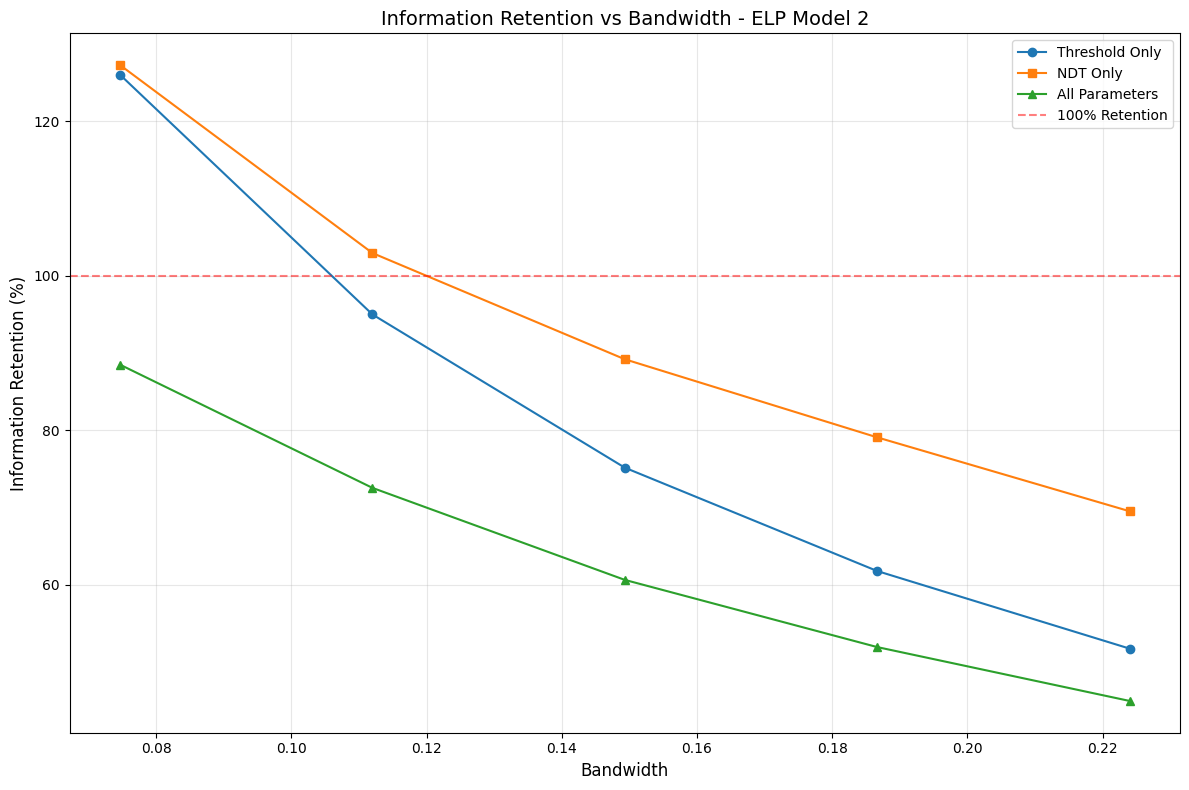

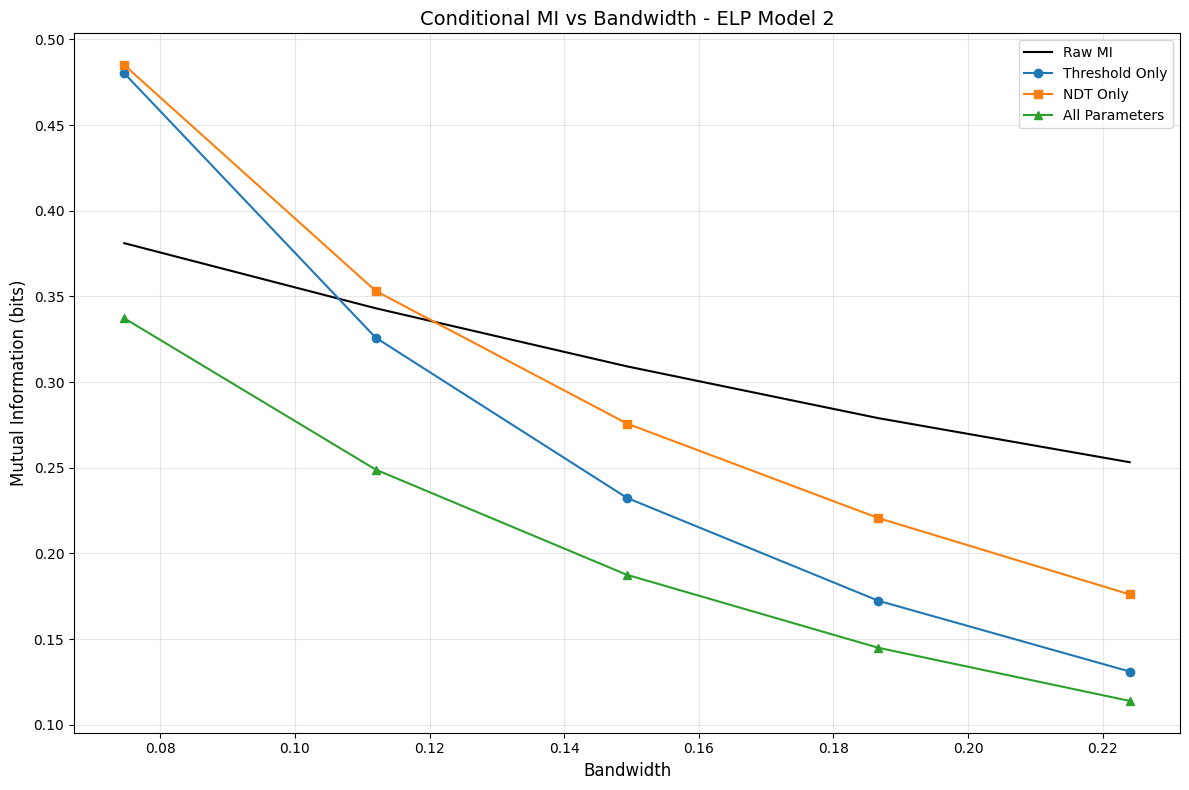

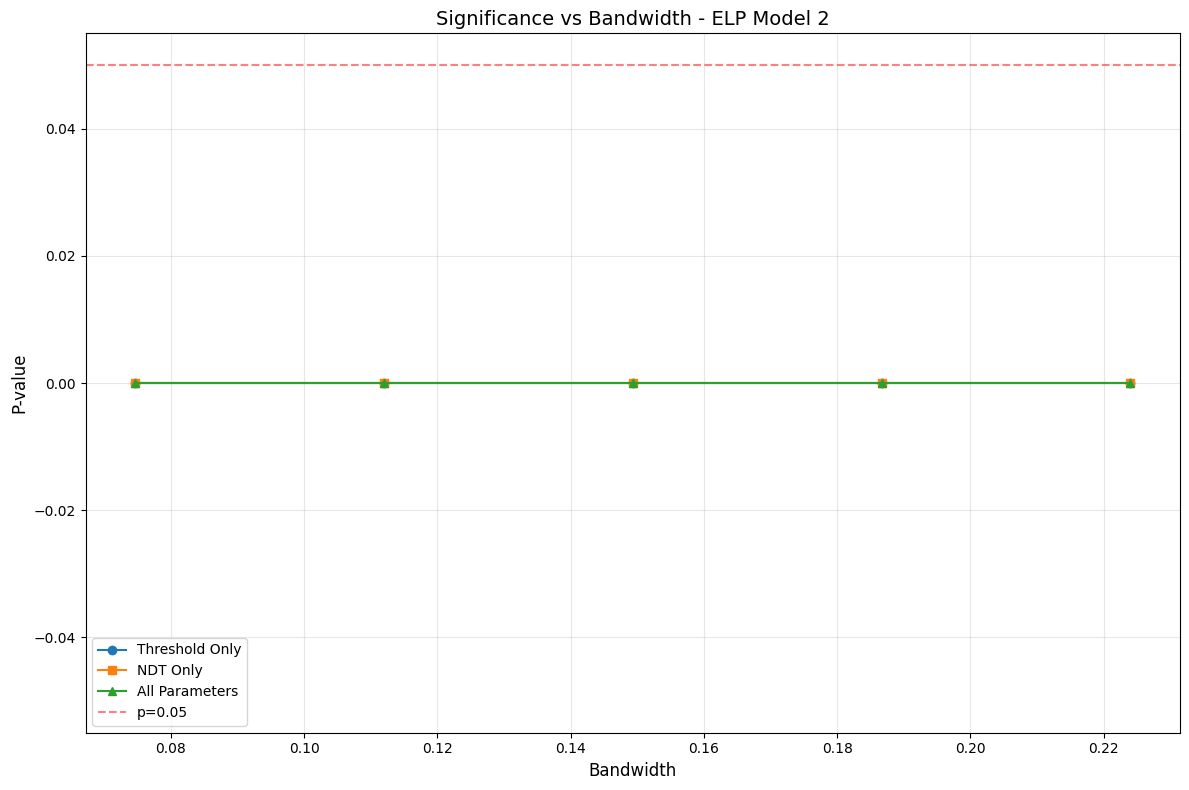


Summary of Results:

Bandwidth: 0.0747
Raw MI: 0.3811 bits
Threshold-only retention: 126.0% (p=0.0000)
NDT-only retention: 127.3% (p=0.0000)
All parameters retention: 88.5% (p=0.0000)

Bandwidth: 0.1120
Raw MI: 0.3431 bits
Threshold-only retention: 95.0% (p=0.0000)
NDT-only retention: 102.9% (p=0.0000)
All parameters retention: 72.6% (p=0.0000)

Bandwidth: 0.1493
Raw MI: 0.3092 bits
Threshold-only retention: 75.2% (p=0.0000)
NDT-only retention: 89.2% (p=0.0000)
All parameters retention: 60.6% (p=0.0000)

Bandwidth: 0.1867
Raw MI: 0.2790 bits
Threshold-only retention: 61.8% (p=0.0000)
NDT-only retention: 79.1% (p=0.0000)
All parameters retention: 52.0% (p=0.0000)

Bandwidth: 0.2240
Raw MI: 0.2532 bits
Threshold-only retention: 51.8% (p=0.0000)
NDT-only retention: 69.5% (p=0.0000)
All parameters retention: 45.0% (p=0.0000)

Analyzing bandwidth: 0.0747
Calculating conditional MI for a_mean_s1...
Calculating conditional MI for a_mean_s2...
Calculating conditional MI for ndt_mean_s1...
Cal

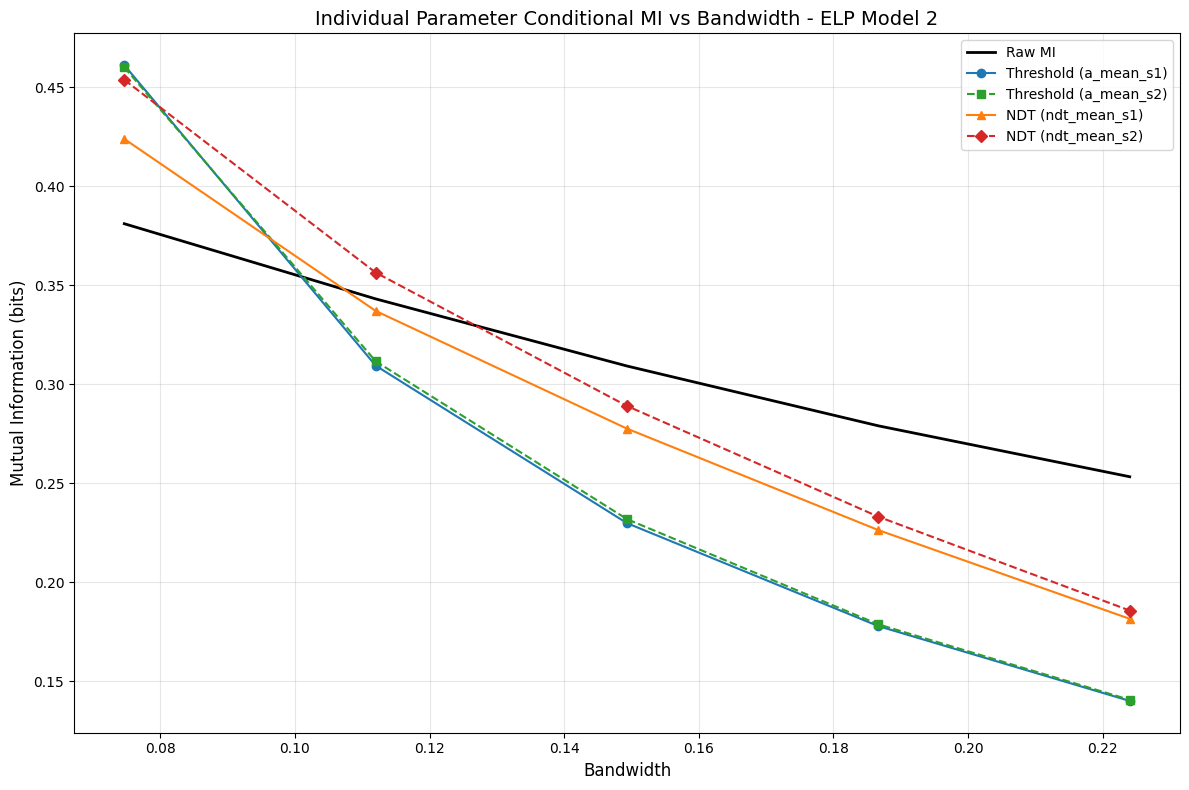

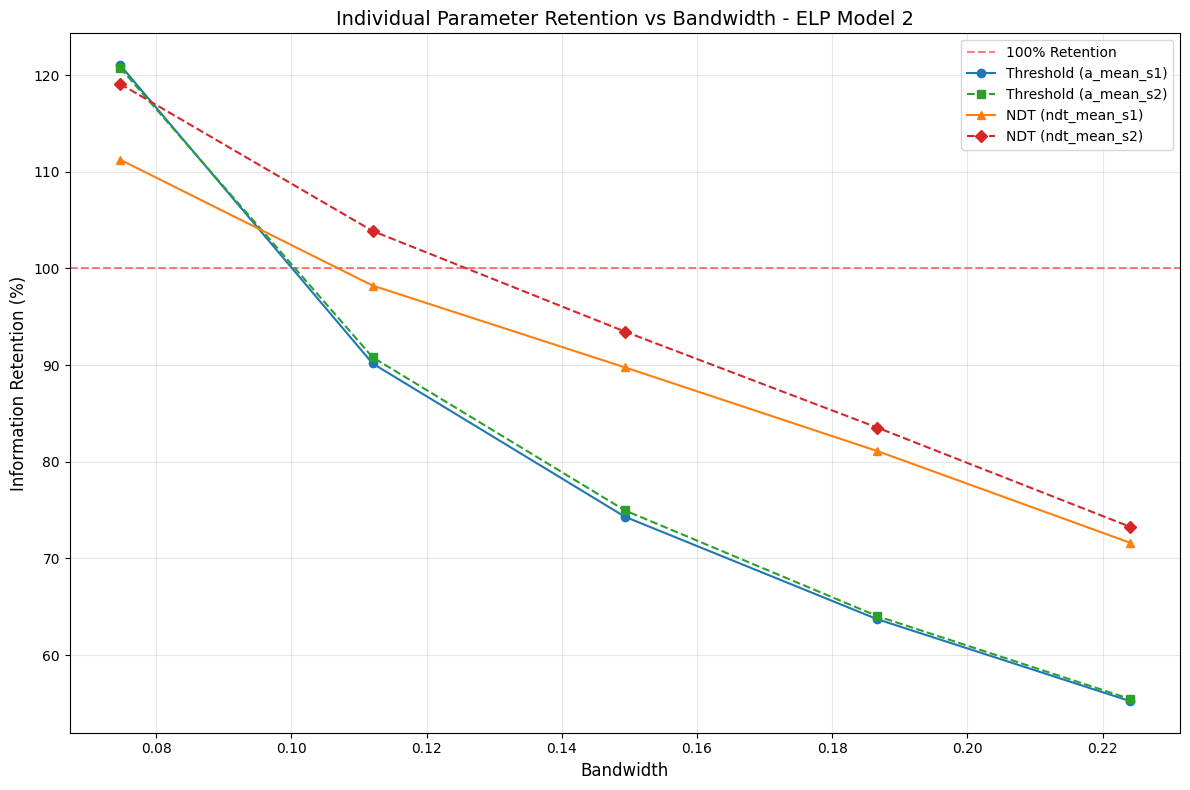

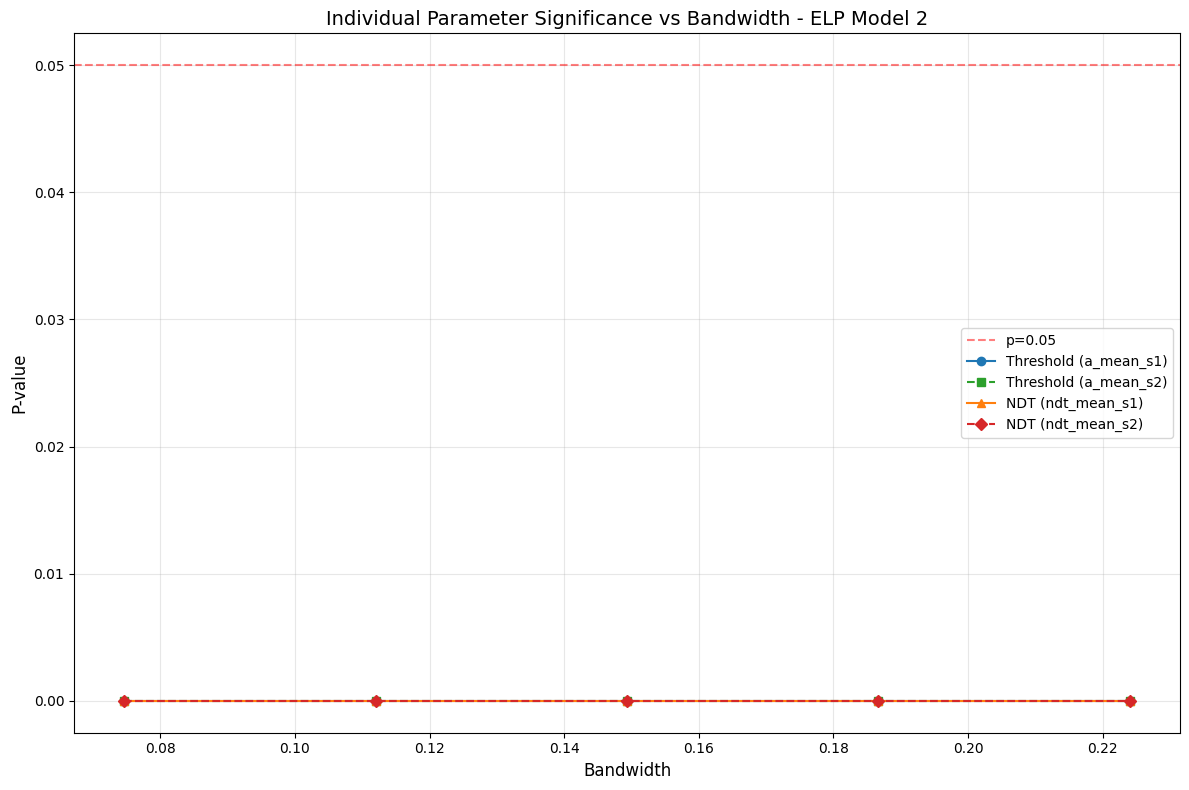

In [6]:
import NewMI_First

# Load your data
session1_path = 'Model2 ELP/Transformed_recoverd_param_ELP_S1_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'
session2_path = 'Model2 ELP/Transformed_recoverd_param_ELP_S2_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'

df_merged = NewMI_First.load_and_merge(session1_path, session2_path)

analyzer = NewMI_First.MutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Define a range of bandwidths to test
# Using a logarithmic scale to better explore the parameter space
base_bandwidth = np.std(analyzer.data['alpha_s1'].values) * (4/(3*len(analyzer.data)))**(1/5)
bandwidths = [
    base_bandwidth * 1.0,  # Original Silverman's rule
    base_bandwidth * 1.5,  # 1.5x Silverman
    base_bandwidth * 2.0,  # 2x Silverman
    base_bandwidth * 2.5,  # 2.5x Silverman
    base_bandwidth * 3.0   # 3x Silverman
]

print(f"Base bandwidth (Silverman's rule): {base_bandwidth:.4f}")
print(f"Testing bandwidths: {[f'{bw:.4f}' for bw in bandwidths]}")

# Set verbose output to False to reduce output clutter
import warnings
warnings.filterwarnings('ignore')

# Run the bandwidth sensitivity analysis for conditional MI
bandwidth_results = analyzer.conditional_mi_bandwidth_sensitivity(
    feature='alpha_s1',
    target='alpha_s2',
    control_vars=control_vars,
    bandwidths=bandwidths,
    alpha=1,  # Shrinkage parameter
    dataset_name="ELP Model 2"
)

# The method automatically produces plots, but we can also print some key results
print("\nSummary of Results:")
for i, bw in enumerate(bandwidth_results['bandwidths']):
    print(f"\nBandwidth: {bw:.4f}")
    print(f"Raw MI: {bandwidth_results['raw_mi'][i]:.4f} bits")
    
    if 'retention_threshold' in bandwidth_results:
        print(f"Threshold-only retention: {bandwidth_results['retention_threshold'][i]:.1f}% (p={bandwidth_results['p_values_threshold'][i]:.4f})")
    
    if 'retention_ndt' in bandwidth_results:
        print(f"NDT-only retention: {bandwidth_results['retention_ndt'][i]:.1f}% (p={bandwidth_results['p_values_ndt'][i]:.4f})")
    
    if 'retention_all' in bandwidth_results:
        print(f"All parameters retention: {bandwidth_results['retention_all'][i]:.1f}% (p={bandwidth_results['p_values_all'][i]:.4f})")

# Run the individual parameter analysis
individual_results = analyzer.individual_parameter_sensitivity(
    feature='alpha_s1',
    target='alpha_s2',
    control_vars=control_vars,
    bandwidths=bandwidths,
    alpha=1,
    dataset_name="ELP Model 2"
)